In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import roc_auc_score, precision_score, precision_recall_fscore_support, recall_score, average_precision_score, confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.ensemble import HistGradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter


import shap
import lightgbm as lgb
import xgboost as xgb
import catboost as cb

In [3]:
df_raw = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data_For Midterm and Final Project.xlsx")
df = df_raw.copy()
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',"OPEN_DATE","NGAYDENHAN",
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT',"NHOMNOMOI",'NHOMNO'
]

In [4]:
df.head(20)

,MJACCTTYPCD,PHUONG THUC CHO VAY,LOAIKH,SEX,BASE_BAL,CURR_BAL,DUNO_QD,CURRENCYCD,OPEN_DATE,NGAYDENHAN,...,MJACCTTYPDESC,ORGNBR,ORGNAME,PARENTORGNBR,PARENTORGNAME,LAISUAT,MUCDICHVAY,NHOMNO,NHOMNOMOI,NHOMNO_TCBS
0,CNS,CV TG NGAY VND,1,ONG,787127020.0,851714900.0,851714900.0,VND,28/12/2010,43902,...,Vay Tieu dung,4,KLB - CN KHANH HOA,4,KLB - CN KHANH HOA,0.120,1900-SX-DV Tu t.dung Gia dinh,1,1,CURR
1,CNS,CV TG NGAY VND,1,ONG,333388030.0,142450650.0,142450650.0,VND,40490,28/07/2030,...,Vay Tieu dung,20,KLB - PGD CAI LANG,19,KLB - CN DA NANG,0.180,1811-CV mua Xe may tra gop,1,1,CURR
2,CNS,CV TG NGAY VND,1,MR,311014800.0,357000690.0,357000690.0,VND,27/05/2010,26/05/2030,...,Vay Tieu dung,19,KLB - CN DA NANG,19,KLB - CN DA NANG,0.180,1870-CV TG Sinh hoat Tieu dung,1,1,CURR
3,CNS,CV TL TH LAI DINH KY VND,1,NaN,35600000.0,35600000.0,35600000.0,VND,40276,41372,...,Vay Tieu dung,64,KLB - PGD DIEN KHANH,4,KLB - CN KHANH HOA,0.240,1830-CV Sua chua Nha de o,5,5,CURR
4,CNS,CV TG NGAY VND,1,MR,430174020.0,88246180.0,88246180.0,VND,23/06/2010,23/06/2030,...,Vay Tieu dung,19,KLB - CN DA NANG,19,KLB - CN DA NANG,0.180,1870-CV TG Sinh hoat Tieu dung,1,1,CURR
5,CNS,CV TG NGAY VND,1,MR,178967050.0,289814360.0,289814360.0,VND,40273,51260,...,Vay Tieu dung,21,KLB - PGD HAI CHAU,19,KLB - CN DA NANG,0.160,1894-Kinh doanh Ca the,1,1,CURR
6,CNS,CV TG NGAY VND,1,ONG,428882950.0,86435880.0,86435880.0,VND,19/11/2008,43445,...,Vay Tieu dung,4,KLB - CN KHANH HOA,4,KLB - CN KHANH HOA,0.180,1900-SX-DV Tu t.dung Gia dinh,1,1,CURR
7,CNS,CV TL NH LAI DINH KY VND,1,ONG,90000000.0,90000000.0,90000000.0,VND,23/10/2010,23/10/2011,...,Vay Tieu dung,66,KLB - PGD NINH HOA,4,KLB - CN KHANH HOA,0.174,1870-CV TG Sinh hoat Tieu dung,5,5,CURR
8,CNS,CV TG NGAY VND,1,MR,559795880.0,560965250.0,560965250.0,VND,40394,47699,...,Vay Tieu dung,64,KLB - PGD DIEN KHANH,4,KLB - CN KHANH HOA,0.000,1850-CV the chap STK,1,1,CURR
9,CNS,CV TG NGAY VND,1,MR,359505410.0,418045960.0,418045960.0,VND,40184,47489,...,Vay Tieu dung,19,KLB - CN DA NANG,19,KLB - CN DA NANG,0.160,1870-CV TG Sinh hoat Tieu dung,1,1,CURR


# INFORMATION

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90344 entries, 0 to 90343
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MJACCTTYPCD          90344 non-null  object 
 1   PHUONG THUC CHO VAY  90344 non-null  object 
 2   LOAIKH               90344 non-null  int64  
 3   SEX                  86014 non-null  object 
 4   BASE_BAL             90344 non-null  float64
 5   CURR_BAL             90344 non-null  float64
 6   DUNO_QD              90344 non-null  float64
 7   CURRENCYCD           90344 non-null  object 
 8   OPEN_DATE            90344 non-null  object 
 9   NGAYDENHAN           90344 non-null  object 
 10  ID_TIME              90344 non-null  int64  
 11  DESC_TIME            90344 non-null  object 
 12  MJACCTTYPDESC        90344 non-null  object 
 13  ORGNBR               90344 non-null  int64  
 14  ORGNAME              90344 non-null  object 
 15  PARENTORGNBR         90344 non-null 

# STATISTICS DESCRIBE

In [6]:
df.describe()

,LOAIKH,BASE_BAL,CURR_BAL,DUNO_QD,ID_TIME,ORGNBR,PARENTORGNBR,LAISUAT,NHOMNO,NHOMNOMOI
count,90344.000000,9.034400e+04,9.034400e+04,9.034400e+04,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000
mean,1.015950,3.824727e+08,3.492253e+08,3.504023e+08,1.306041,62.705703,44.470435,0.090739,1.260183,1.278491
std,0.125283,4.389216e+09,3.828898e+09,3.830033e+09,0.615677,36.059407,33.218565,0.055570,0.881587,0.901262
min,1.000000,2.000000e+00,1.000000e+00,1.000000e+00,1.000000,3.000000,3.000000,0.000000,1.000000,1.000000
25%,1.000000,2.200000e+07,3.000000e+07,3.000000e+07,1.000000,33.000000,19.000000,0.000000,1.000000,1.000000
50%,1.000000,1.200000e+08,1.100000e+08,1.100000e+08,1.000000,66.000000,34.000000,0.111000,1.000000,1.000000
75%,1.000000,3.000000e+08,3.000000e+08,3.000000e+08,1.000000,90.000000,73.000000,0.129000,1.000000,1.000000
max,2.000000,3.850000e+11,3.127000e+11,3.127000e+11,3.000000,138.000000,138.000000,0.950000,5.000000,5.000000


In [7]:
df[['LOAIKH', 'BASE_BAL', 'CURR_BAL','DUNO_QD','ID_TIME']].describe()

,LOAIKH,BASE_BAL,CURR_BAL,DUNO_QD,ID_TIME
count,90344.000000,9.034400e+04,9.034400e+04,9.034400e+04,90344.000000
mean,1.015950,3.824727e+08,3.492253e+08,3.504023e+08,1.306041
std,0.125283,4.389216e+09,3.828898e+09,3.830033e+09,0.615677
min,1.000000,2.000000e+00,1.000000e+00,1.000000e+00,1.000000
25%,1.000000,2.200000e+07,3.000000e+07,3.000000e+07,1.000000
50%,1.000000,1.200000e+08,1.100000e+08,1.100000e+08,1.000000
75%,1.000000,3.000000e+08,3.000000e+08,3.000000e+08,1.000000
max,2.000000,3.850000e+11,3.127000e+11,3.127000e+11,3.000000


In [8]:
df[['ORGNBR', 'PARENTORGNBR', 'LAISUAT','NHOMNO','NHOMNOMOI']].describe()

,ORGNBR,PARENTORGNBR,LAISUAT,NHOMNO,NHOMNOMOI
count,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000
mean,62.705703,44.470435,0.090739,1.260183,1.278491
std,36.059407,33.218565,0.055570,0.881587,0.901262
min,3.000000,3.000000,0.000000,1.000000,1.000000
25%,33.000000,19.000000,0.000000,1.000000,1.000000
50%,66.000000,34.000000,0.111000,1.000000,1.000000
75%,90.000000,73.000000,0.129000,1.000000,1.000000
max,138.000000,138.000000,0.950000,5.000000,5.000000


# NORMALIZATION

In [9]:
df = df[selected_columns]
df["OPEN_DATE_clean"] = pd.NaT

mask_numeric = df["OPEN_DATE"].apply(lambda x: str(x).replace('.', '').isnumeric())

mask_string = ~mask_numeric

df.loc[mask_numeric, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_numeric, "OPEN_DATE"].astype(float),
                                                         origin="1899-12-30", unit="D", errors="coerce")

df.loc[mask_string, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_string, "OPEN_DATE"],
                                                        format="%d/%m/%Y", errors="coerce")

print(df[["OPEN_DATE", "OPEN_DATE_clean"]].head())

invalid_dates = df[df["OPEN_DATE_clean"].isna()]

num_invalid = invalid_dates.shape[0]
print(f"Số lượng giá trị lỗi trong OPEN_DATE_clean: {num_invalid}")

df["NGAYDENHAN_clean"] = pd.NaT
mask_numeric_ngay = df["NGAYDENHAN"].apply(lambda x: str(x).replace('.', '').isnumeric())
mask_string_ngay = ~mask_numeric_ngay

df.loc[mask_numeric_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_numeric_ngay, "NGAYDENHAN"].astype(float),
    origin="1899-12-30", unit="D", errors="coerce"
)
df.loc[mask_string_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_string_ngay, "NGAYDENHAN"],
    format="%d/%m/%Y", errors="coerce"
)

# Sửa lỗi năm 2121 thành 2021
wrong_date = pd.to_datetime("2121-04-30")
correct_date = pd.to_datetime("2021-04-30")
df.loc[df["NGAYDENHAN_clean"] == wrong_date, "NGAYDENHAN_clean"] = correct_date

# Chuẩn hóa giới tính
sex_mapping = {
    'ONG': 'MR', 'MR': 'MR',
    'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'
}
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')

    OPEN_DATE OPEN_DATE_clean
0  28/12/2010      2010-12-28
1       40490      2010-11-08
2  27/05/2010      2010-05-27
3       40276      2010-04-08
4  23/06/2010      2010-06-23
Số lượng giá trị lỗi trong OPEN_DATE_clean: 0


In [10]:
num_invalid = invalid_dates.shape[0]
print(f"Error value in OPEN_DATE_clean: {num_invalid}")

Error value in OPEN_DATE_clean: 0


In [11]:
df['OPEN_DATE'] = pd.to_datetime(df['OPEN_DATE'], errors='coerce')
df['NGAYDENHAN'] = pd.to_datetime(df['NGAYDENHAN'], errors='coerce')
# Calculate loan duration
df['LOAN_DURATION'] = (df['NGAYDENHAN'] - df['OPEN_DATE']).dt.days

# Feature engineering
df['LOAN_TO_BALANCE_RATIO'] = df['CURR_BAL'] / df['BASE_BAL']

# MISSING 

In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
df = df.iloc[:50000]

# 5 GROUP

In [13]:
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',"OPEN_DATE","NGAYDENHAN",
    'BASE_BAL', 'DUNO_QD', 'LAISUAT',"NHOMNOMOI",'NHOMNO', 'LOAN_DURATION','LOAN_TO_BALANCE_RATIO'
]

In [14]:
df = df[selected_columns]

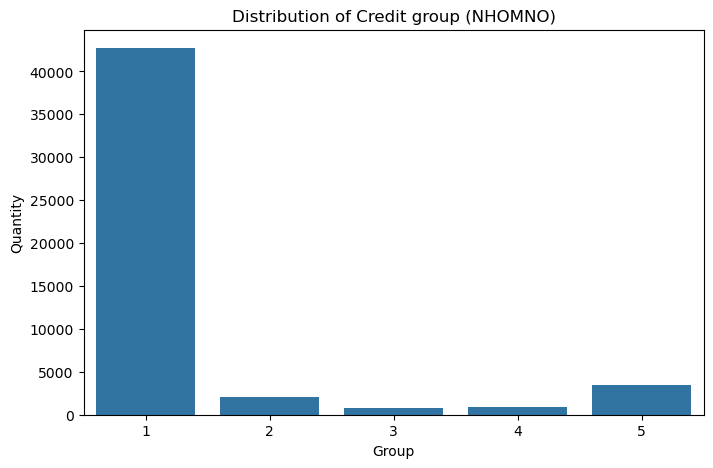

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x="NHOMNO", data=df)
plt.title("Distribution of Credit group (NHOMNO)")
plt.xlabel("Group")
plt.ylabel("Quantity")
plt.show()

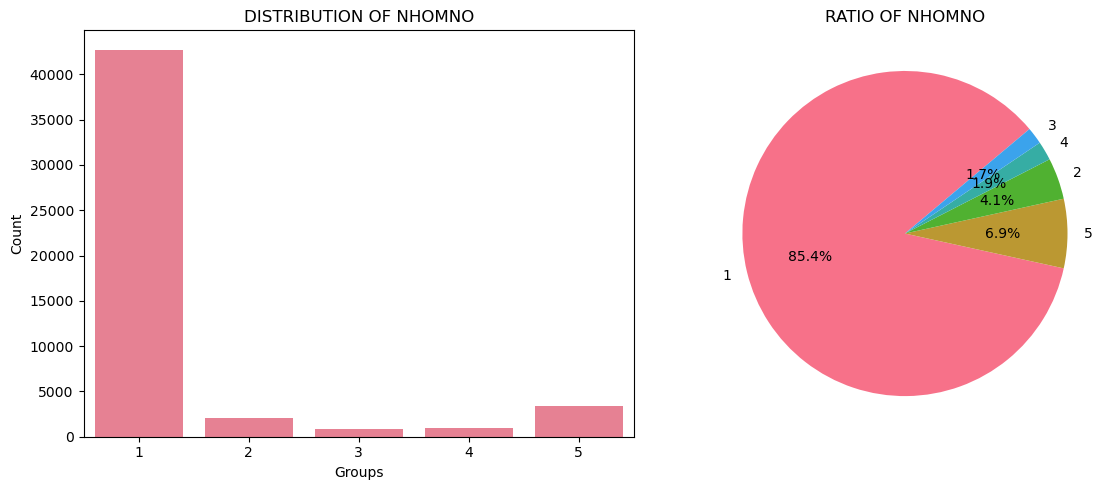

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='NHOMNO')
plt.title('DISTRIBUTION OF NHOMNO')
plt.xlabel('Groups')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['NHOMNO'].value_counts().plot.pie(autopct='%1.1f%%', startangle=40)
plt.title('RATIO OF NHOMNO')
plt.ylabel('')

plt.tight_layout()
plt.show()

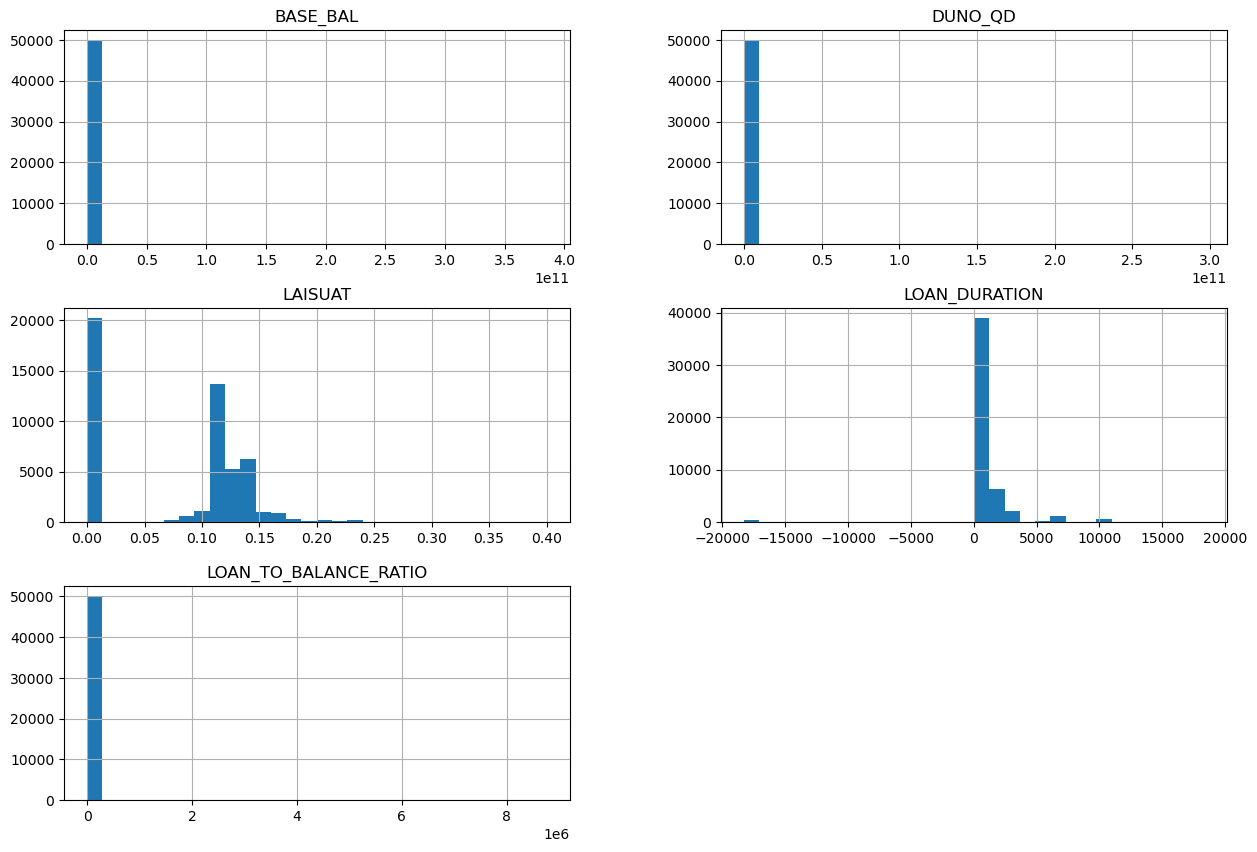

In [16]:
num_features = ['BASE_BAL', 'DUNO_QD', 'LAISUAT', 'LOAN_DURATION', 'LOAN_TO_BALANCE_RATIO']
df[num_features].hist(bins=30, figsize=(15,10))
plt.show()

In [17]:
def create_multiclass_target(row):
    """
    Tạo 5 nhóm rủi ro tín dụng đa chiều dựa trên NHOMNO, LAISUAT và DUNO_QD
    
    Parameters:
    -----------
    row : pandas.Series
        Dòng dữ liệu chứa các đặc trưng cần thiết
        
    Returns:
    --------
    int
        Nhóm rủi ro từ 1-5, trong đó:
        - 1: Rủi ro thấp nhất
        - 5: Rủi ro cao nhất
    """
    
    # Nhóm 5: Nợ xấu - giữ nguyên nhóm 5 từ NHOMNO
    if row['NHOMNO'] == 5:
        return 5
    
    # Tính điểm rủi ro tổng hợp dựa trên lãi suất và dư nợ
    risk_score = 0
    
    # Đánh giá rủi ro từ lãi suất (LAISUAT)
    if row['LAISUAT'] <= 0.08:
        risk_score += 1  # Lãi suất rất thấp
    elif row['LAISUAT'] <= 0.12:
        risk_score += 2  # Lãi suất thấp
    elif row['LAISUAT'] <= 0.15:
        risk_score += 3  # Lãi suất trung bình
    elif row['LAISUAT'] <= 0.18:
        risk_score += 4  # Lãi suất cao
    else:
        risk_score += 5  # Lãi suất rất cao
    
    # Đánh giá rủi ro từ dư nợ (DUNO_QD)
    # Sử dụng phân vị để xác định mức độ rủi ro của dư nợ
    if row['DUNO_QD'] <= 100000000:      # Dưới 100 triệu
        risk_score += 1  # Dư nợ thấp
    elif row['DUNO_QD'] <= 500000000:    # 100 triệu - 500 triệu
        risk_score += 2  # Dư nợ trung bình thấp
    elif row['DUNO_QD'] <= 1000000000:   # 500 triệu - 1 tỷ
        risk_score += 3  # Dư nợ trung bình
    elif row['DUNO_QD'] <= 3000000000:   # 1 tỷ - 3 tỷ
        risk_score += 4  # Dư nợ cao
    else:
        risk_score += 5  # Dư nợ rất cao
    
    # Phân loại dựa trên tổng điểm rủi ro
    total_risk_score = risk_score
    
    # Điều chỉnh phân loại dựa trên NHOMNO ban đầu
    if row['NHOMNO'] == 1:
        # Nhóm nợ đủ tiêu chuẩn - phân loại chi tiết
        if total_risk_score <= 3:
            return 1  # Rủi ro rất thấp
        elif total_risk_score <= 5:
            return 2  # Rủi ro thấp
        elif total_risk_score <= 7:
            return 3  # Rủi ro trung bình
        else:
            return 4  # Rủi ro cao (trong nhóm đủ tiêu chuẩn)
    
    elif row['NHOMNO'] == 2:
        # Nhóm cần chú ý - nâng mức rủi ro
        base_risk = max(3, min(5, total_risk_score - 1))
        return base_risk
    
    elif row['NHOMNO'] == 3:
        # Nhóm dưới tiêu chuẩn - rủi ro cao
        base_risk = max(4, min(5, total_risk_score))
        return base_risk
    
    elif row['NHOMNO'] == 4:
        # Nhóm nghi ngờ - gần như nợ xấu
        return 5  # Luôn xếp vào nhóm rủi ro cao nhất
    
    # Trường hợp mặc định
    return 3

# Áp dụng hàm để tạo biến mục tiêu
df['target'] = df.apply(create_multiclass_target, axis=1)

# Phân tích phân bố của các nhóm mới
print("Phân bố các nhóm rủi ro mới:")
print(df['target'].value_counts().sort_index())

# Kiểm tra mối quan hệ giữa các đặc trưng và nhóm mục tiêu
print("\nThống kê LAISUAT theo nhóm mục tiêu:")
print(df.groupby('target')['LAISUAT'].describe())

print("\nThống kê DUNO_QD theo nhóm mục tiêu:")
print(df.groupby('target')['DUNO_QD'].describe())

Phân bố các nhóm rủi ro mới:
target
1    21042
2    19379
3     3678
4     1160
5     4741
Name: count, dtype: int64

Thống kê LAISUAT theo nhóm mục tiêu:
          count      mean       std  min     25%    50%     75%     max
target                                                                 
1       21042.0  0.009731  0.031157  0.0  0.0000  0.000  0.0000  0.1200
2       19379.0  0.123297  0.012809  0.0  0.1143  0.120  0.1340  0.1800
3        3678.0  0.116177  0.047938  0.0  0.1110  0.120  0.1494  0.4000
4        1160.0  0.100972  0.052518  0.0  0.1100  0.120  0.1290  0.2088
5        4741.0  0.130158  0.052188  0.0  0.1118  0.126  0.1500  0.4000

Thống kê DUNO_QD theo nhóm mục tiêu:
          count          mean           std     min           25%  \
target                                                              
1       21042.0  2.179580e+07  3.418423e+07     1.0  3.346012e+06   
2       19379.0  2.527811e+08  2.051970e+08  3645.0  1.000000e+08   
3        3678.0  1.750320e+

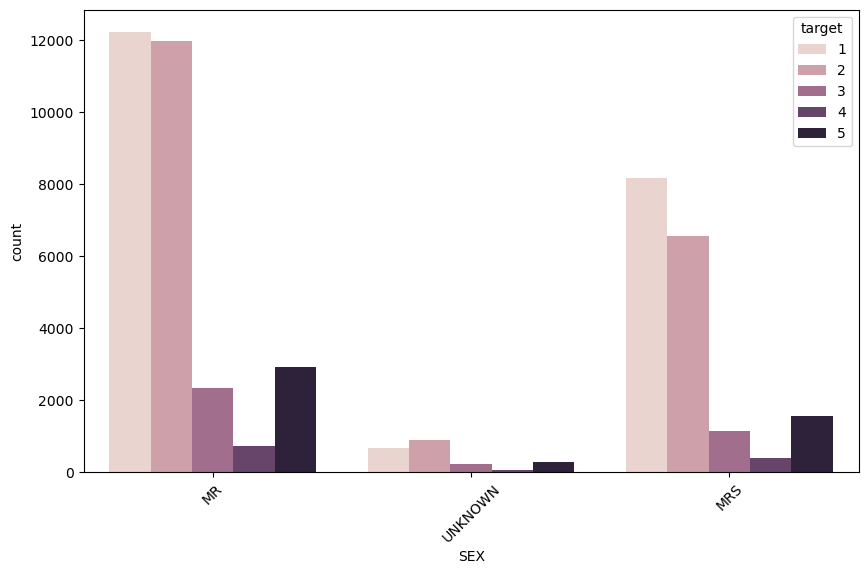

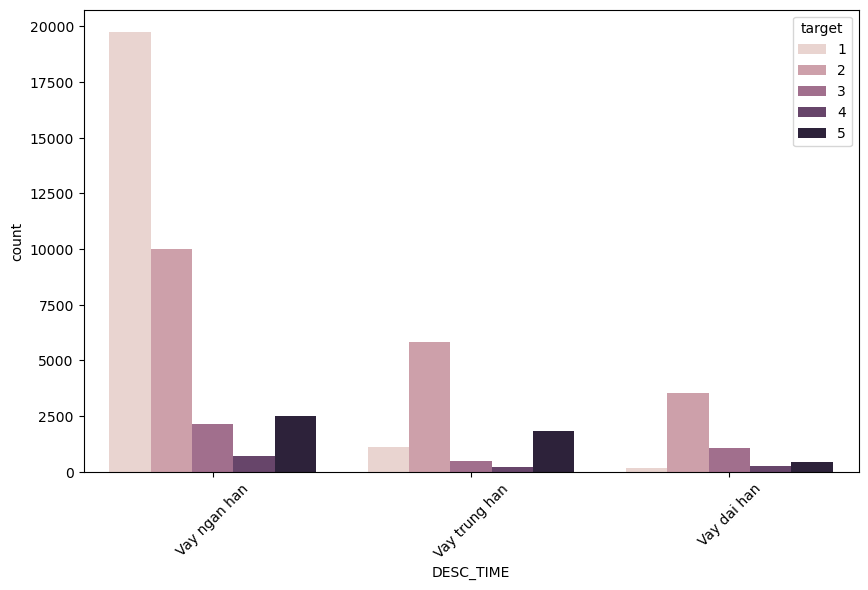

In [18]:
cat_features = ['SEX', 'DESC_TIME']
for feature in cat_features:
    plt.figure(figsize=(10,6))
    sns.countplot(x=feature, hue='target', data=df)
    plt.xticks(rotation=45)
    plt.show()

Target

In [19]:
def create_multiclass_target(row):
    """
    Tạo 5 nhóm rủi ro tín dụng đa chiều dựa trên NHOMNO, LAISUAT và DUNO_QD
    
    Parameters:
    -----------
    row : pandas.Series
        Dòng dữ liệu chứa các đặc trưng cần thiết
        
    Returns:
    --------
    int
        Nhóm rủi ro từ 1-5, trong đó:
        - 1: Rủi ro thấp nhất
        - 5: Rủi ro cao nhất
    """
    
    # Nhóm 5: Nợ xấu - giữ nguyên nhóm 5 từ NHOMNO
    if row['NHOMNO'] == 5:
        return 5
    
    # Tính điểm rủi ro tổng hợp dựa trên lãi suất và dư nợ
    risk_score = 0
    
    # Đánh giá rủi ro từ lãi suất (LAISUAT)
    if row['LAISUAT'] <= 0.08:
        risk_score += 1  # Lãi suất rất thấp
    elif row['LAISUAT'] <= 0.12:
        risk_score += 2  # Lãi suất thấp
    elif row['LAISUAT'] <= 0.15:
        risk_score += 3  # Lãi suất trung bình
    elif row['LAISUAT'] <= 0.18:
        risk_score += 4  # Lãi suất cao
    else:
        risk_score += 5  # Lãi suất rất cao
    
    # Đánh giá rủi ro từ dư nợ (DUNO_QD)
    # Sử dụng phân vị để xác định mức độ rủi ro của dư nợ
    if row['DUNO_QD'] <= 100000000:      # Dưới 100 triệu
        risk_score += 1  # Dư nợ thấp
    elif row['DUNO_QD'] <= 500000000:    # 100 triệu - 500 triệu
        risk_score += 2  # Dư nợ trung bình thấp
    elif row['DUNO_QD'] <= 1000000000:   # 500 triệu - 1 tỷ
        risk_score += 3  # Dư nợ trung bình
    elif row['DUNO_QD'] <= 3000000000:   # 1 tỷ - 3 tỷ
        risk_score += 4  # Dư nợ cao
    else:
        risk_score += 5  # Dư nợ rất cao
    
    # Phân loại dựa trên tổng điểm rủi ro
    total_risk_score = risk_score
    
    # Điều chỉnh phân loại dựa trên NHOMNO ban đầu
    if row['NHOMNO'] == 1:
        # Nhóm nợ đủ tiêu chuẩn - phân loại chi tiết
        if total_risk_score <= 3:
            return 1  # Rủi ro rất thấp
        elif total_risk_score <= 5:
            return 2  # Rủi ro thấp
        elif total_risk_score <= 7:
            return 3  # Rủi ro trung bình
        else:
            return 4  # Rủi ro cao (trong nhóm đủ tiêu chuẩn)
    
    elif row['NHOMNO'] == 2:
        # Nhóm cần chú ý - nâng mức rủi ro
        base_risk = max(3, min(5, total_risk_score - 1))
        return base_risk
    
    elif row['NHOMNO'] == 3:
        # Nhóm dưới tiêu chuẩn - rủi ro cao
        base_risk = max(4, min(5, total_risk_score))
        return base_risk
    
    elif row['NHOMNO'] == 4:
        # Nhóm nghi ngờ - gần như nợ xấu
        return 5  # Luôn xếp vào nhóm rủi ro cao nhất
    
    # Trường hợp mặc định
    return 3

# Áp dụng hàm để tạo biến mục tiêu
df['target'] = df.apply(create_multiclass_target, axis=1)

# Phân tích phân bố của các nhóm mới
print("Phân bố các nhóm rủi ro mới:")
print(df['target'].value_counts().sort_index())

# Kiểm tra mối quan hệ giữa các đặc trưng và nhóm mục tiêu
print("\nThống kê LAISUAT theo nhóm mục tiêu:")
print(df.groupby('target')['LAISUAT'].describe())

print("\nThống kê DUNO_QD theo nhóm mục tiêu:")
print(df.groupby('target')['DUNO_QD'].describe())

Phân bố các nhóm rủi ro mới:
target
1    21042
2    19379
3     3678
4     1160
5     4741
Name: count, dtype: int64

Thống kê LAISUAT theo nhóm mục tiêu:
          count      mean       std  min     25%    50%     75%     max
target                                                                 
1       21042.0  0.009731  0.031157  0.0  0.0000  0.000  0.0000  0.1200
2       19379.0  0.123297  0.012809  0.0  0.1143  0.120  0.1340  0.1800
3        3678.0  0.116177  0.047938  0.0  0.1110  0.120  0.1494  0.4000
4        1160.0  0.100972  0.052518  0.0  0.1100  0.120  0.1290  0.2088
5        4741.0  0.130158  0.052188  0.0  0.1118  0.126  0.1500  0.4000

Thống kê DUNO_QD theo nhóm mục tiêu:
          count          mean           std     min           25%  \
target                                                              
1       21042.0  2.179580e+07  3.418423e+07     1.0  3.346012e+06   
2       19379.0  2.527811e+08  2.051970e+08  3645.0  1.000000e+08   
3        3678.0  1.750320e+

In [20]:
assert df['target'].value_counts().get(1,0) >= 4000, "Nhóm 1 không đủ 4000 mẫu"
assert df['target'].value_counts().get(2,0) >= 4000, "Nhóm 2 không đủ 4000 mẫu"

df1 = df[df['target']==1].sample(n=5000, random_state=42)
df2 = df[df['target']==2].sample(n=5000, random_state=42)
df_rest = df[~df['target'].isin([1,2])]   # giữ tất cả các bản ghi thuộc nhóm 3/4/5

df_sampled = pd.concat([df1, df2, df_rest], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

# kiểm tra
print(df_sampled['target'].value_counts())

target
1    5000
2    5000
5    4741
3    3678
4    1160
Name: count, dtype: int64


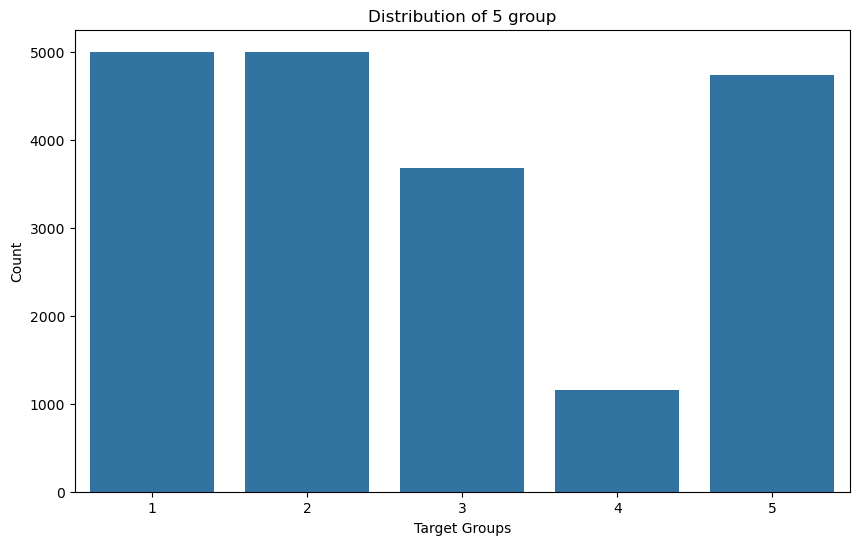

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_sampled, x='target')
plt.title('Distribution of 5 group')
plt.xlabel('Target Groups')
plt.ylabel('Count')
plt.show()

# CORRELATION

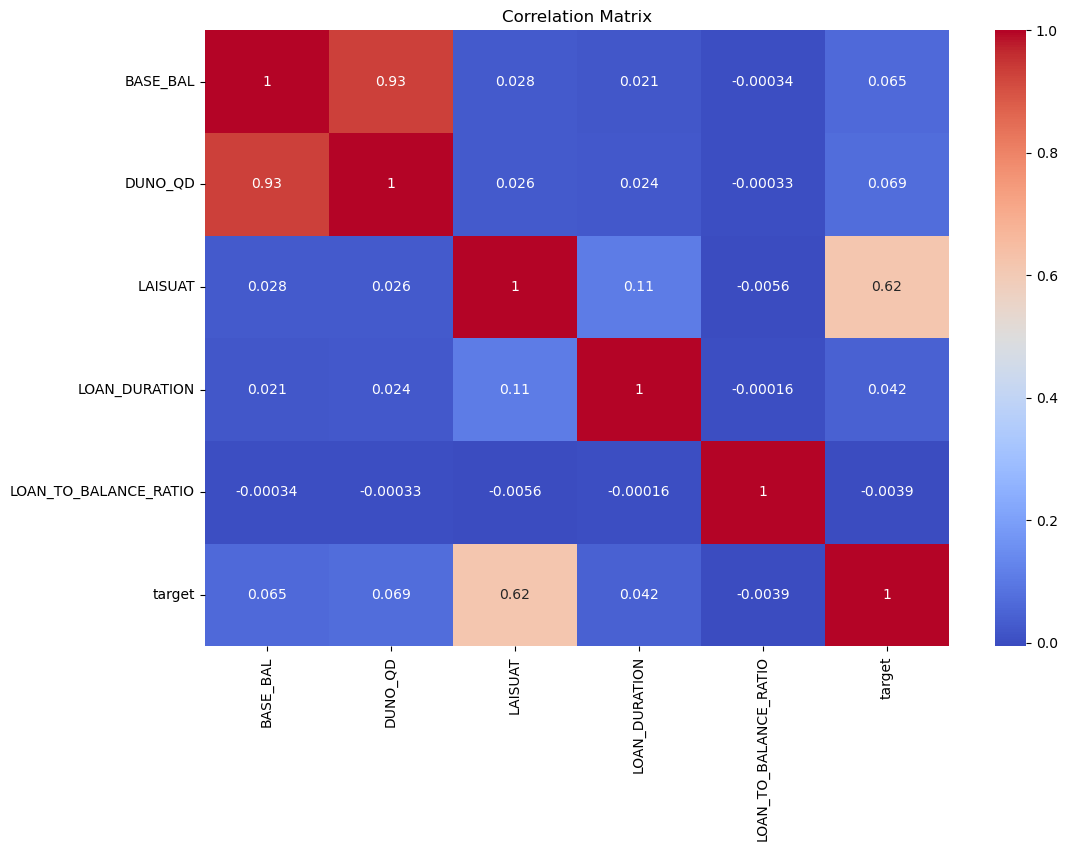

In [22]:
corr_matrix = df[num_features + ['target']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

CREDIT SCORING MODEL BENCHMARK
Đang load dữ liệu... (có thể hơi lâu)
✓ Done! Shape: (90344, 22)
Missing values: 4330
Duplicate rows: 1012
Tạo biến target...
Default rate: 2.41%
 Default rate khá thấp, có thể cần cân nhắc sampling techniques
Bắt đầu feature engineering...
  → Xử lý demographics features...
  → Xử lý balance features...
  → Xử lý time features...
      open_date_num: 63.2% missing
      loan_term_days: 64.8% missing
  ✓ Giữ lại 10 features
Chuẩn bị data cho modeling...
Data sau khi clean: (90344, 37)
Final dataset: 90344 samples, 10 features
Sẽ benchmark 6 models: ['Logistic', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'NeuralNet']

RUNNING BENCHMARK
Chạy 5-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...
  → Đang test XGBoost...
  → Đang test CatBoost...
      Lỗi ở fold 0: catboost/private/libs/options/json_helper.h:41: Can't parse parameter "class_weights" with value: "Balanced"
      Lỗi ở fold 1: catb

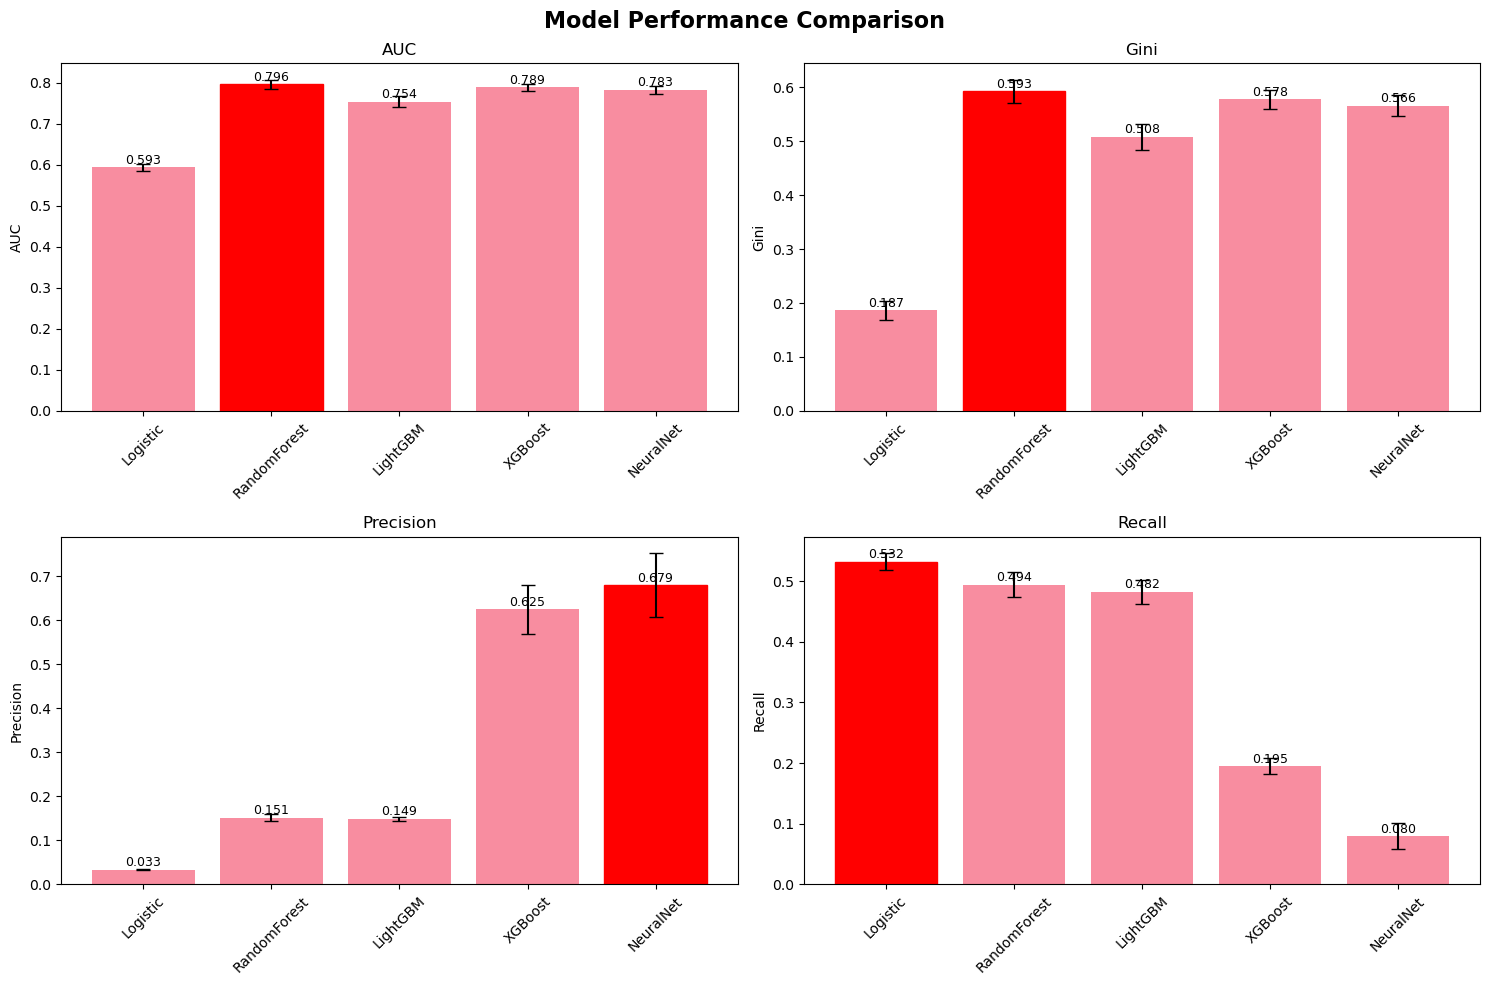


ABLATION STUDY
Chạy ablation study...
  → Baseline (all features)...
Chạy 3-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...
  → Testing without demographics...
Chạy 3-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...
  → Testing without balance...
      Skip balance - quá ít features còn lại
  → Testing without time...
Chạy 3-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...

ABLATION STUDY ANALYSIS

Marginal contribution của từng nhóm features:
--------------------------------------------------

DEMOGRAPHICS Features:
  Logistic    : +0.0041 (+0.7%)
  RandomForest: +0.0036 (+0.5%)
  LightGBM    : +0.0031 (+0.4%)

TIME Features:
  Logistic    : +0.0233 (+3.9%)
  RandomForest: +0.0050 (+0.6%)
  LightGBM    : +0.0027 (+0.4%)

 BENCHMARK COMPLETED!


In [23]:
plt.style.use('default')
sns.set_palette("husl")

def load_data(file_path):

    print("Đang load dữ liệu... (có thể hơi lâu)")
    
    try:
        df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/NGHIÊN CỨU KHOA HỌC/Data_For Midterm and Final Project.xlsx")
        print(f"✓ Done! Shape: {df.shape}")
        
        # Quick check data quality
        print(f"Missing values: {df.isnull().sum().sum()}")
        print(f"Duplicate rows: {df.duplicated().sum()}")
        
        return df
    except Exception as e:
        print(f"Lỗi khi load file: {e}")
        return None

def create_target_variable(df):
    """
    Tạo biến target cho bài toán classification
    
    Logic: NHOMNO_TCBS != 'CURR' thì coi là default (bad debt)
    """
    
    print("Tạo biến target...")
    
    # Tạo binary target
    df['is_default'] = (df['NHOMNO_TCBS'] != 'CURR').astype(int)
    
    # Check distribution
    default_rate = df['is_default'].mean()
    print(f"Default rate: {default_rate:.2%}")
    
    if default_rate < 0.05:
        print(" Default rate khá thấp, có thể cần cân nhắc sampling techniques")
    elif default_rate > 0.3:
        print(" Default rate khá cao, cần kiểm tra lại logic tạo target")
    else:
        print("✓ Default rate hợp lý")
    
    return df

def engineer_features(df):
    """
    Feature engineering
    
    Chia features thành 3 nhóm chính:
    1. Demographics: thông tin cá nhân
    2. Balance: các chỉ số tài chính  
    3. Time: các features liên quan thời gian
    """
    print("Bắt đầu feature engineering...")
    
    df_work = df.copy()  # Tránh modify original data
    
    # === DEMOGRAPHICS FEATURES ===
    print("  → Xử lý demographics features...")
    
    # Encode sex
    le_sex = LabelEncoder()
    df_work['sex_encoded'] = le_sex.fit_transform(df_work['SEX'].fillna('Unknown'))
    
    # Encode Type of customers
    le_customer = LabelEncoder()
    df_work['customer_type'] = le_customer.fit_transform(df_work['LOAIKH'].fillna(0))
    
    demographics_features = ['sex_encoded', 'customer_type']
    
    # === BALANCE FEATURES ===
    print("  → Xử lý balance features...")
    
    # Tránh chia cho 0
    df_work['base_bal_safe'] = df_work['BASE_BAL'].replace(0, 1)
    
    # Các ratio quan trọng trong credit scoring
    df_work['current_vs_base_ratio'] = df_work['CURR_BAL'] / df_work['base_bal_safe']
    df_work['outstanding_vs_base_ratio'] = df_work['DUNO_QD'] / df_work['base_bal_safe']
    df_work['utilization_ratio'] = df_work['DUNO_QD'] / (df_work['CURR_BAL'] + 1)
    
    # Log transform cho các biến có skewness cao
    balance_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD']
    for col in balance_cols:
        df_work[f'{col.lower()}_log'] = np.log1p(df_work[col])
    
    # Interest rate - feature quan trọng
    df_work['interest_rate'] = df_work['LAISUAT'].fillna(df_work['LAISUAT'].median())
    
    balance_features = ['current_vs_base_ratio', 'outstanding_vs_base_ratio', 
                       'utilization_ratio', 'base_bal_log', 'curr_bal_log', 
                       'duno_qd_log', 'interest_rate']
    
    # === TIME FEATURES ===
    print("  → Xử lý time features...")
    
    # Convert dates to numeric (Excel serial dates)
    df_work['open_date_num'] = pd.to_numeric(df_work['OPEN_DATE'], errors='coerce')
    df_work['maturity_date_num'] = pd.to_numeric(df_work['NGAYDENHAN'], errors='coerce')
    
    # Loan term (kỳ hạn vay)
    df_work['loan_term_days'] = df_work['maturity_date_num'] - df_work['open_date_num']
    
    # Time ID có thể chứa thông tin seasonal
    df_work['time_id'] = df_work['ID_TIME']
    
    time_features = ['open_date_num', 'loan_term_days', 'time_id']
    
    # === CLEAN UP FEATURES ===
    # Remove features with too many missing values
    all_features = demographics_features + balance_features + time_features
    
    # Check missing rate
    feature_missing = {}
    for feature in all_features:
        if feature in df_work.columns:
            missing_rate = df_work[feature].isnull().mean()
            feature_missing[feature] = missing_rate
            if missing_rate > 0.5:
                print(f"      {feature}: {missing_rate:.1%} missing")
    
    # Keep only features with reasonable missing rate
    final_features = [f for f in all_features 
                     if f in df_work.columns and feature_missing.get(f, 0) < 0.3]
    
    print(f"  ✓ Giữ lại {len(final_features)} features")
    
    # Define feature groups for ablation study
    feature_groups = {
        'demographics': [f for f in demographics_features if f in final_features],
        'balance': [f for f in balance_features if f in final_features], 
        'time': [f for f in time_features if f in final_features]
    }
    
    return df_work, final_features, feature_groups

def setup_models():
    """
    Setup các models để benchmark
    
    Note: Hyperparameters có thể optimize thêm
    """
    models = {
        'Logistic': LogisticRegression(
            random_state=42, 
            max_iter=1000,
            class_weight='balanced'
        ),
        
        'RandomForest': RandomForestClassifier(
            n_estimators=1000,
            max_depth=10,
            random_state=42,
            class_weight='balanced'
        ),
        
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=1000,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            class_weight='balanced',
            verbose=-1
        ),
        
        'XGBoost': xgb.XGBClassifier(
            n_estimators=1000,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric='logloss'
        ),
        
        'CatBoost': cb.CatBoostClassifier(
            iterations=1000,
            depth=6,
            learning_rate=0.1,
            random_state=42,
            verbose=False,
            class_weights='Balanced'
        ),
        
        'NeuralNet': MLPClassifier(
            hidden_layer_sizes=(64, 32),
            random_state=42,
            max_iter=300,
            early_stopping=True
        )
    }
    
    return models

def calculate_metrics(y_true, y_pred, y_prob):
    """
    Tính các metrics theo yêu cầu đề bài
    """
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1  # Gini = 2*AUC - 1
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary'
    )
    
    return {
        'AUC': auc,
        'Gini': gini, 
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

def run_cv_benchmark(models, X, y, cv_folds=5):
    """
    Chạy cross-validation benchmark
    
    Dùng StratifiedKFold để đảm bảo distribution của target giống nhau
    across các folds
    """
    print(f"Chạy {cv_folds}-fold cross validation...")
    
    # Setup CV
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    results = {}
    
    for model_name, model in models.items():
        print(f"  → Đang test {model_name}...")
        
        fold_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
            # Split data
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            try:
                # Train model
                model.fit(X_train, y_train)
                
                # Predict
                y_pred = model.predict(X_val)
                y_prob = model.predict_proba(X_val)[:, 1]
                
                # Calculate metrics
                metrics = calculate_metrics(y_val, y_pred, y_prob)
                fold_scores.append(metrics)
                
            except Exception as e:
                print(f"      Lỗi ở fold {fold_idx}: {e}")
                continue
        
        # Aggregate results
        if fold_scores:
            results[model_name] = {}
            for metric in ['AUC', 'Gini', 'Precision', 'Recall', 'F1']:
                scores = [fold[metric] for fold in fold_scores]
                results[model_name][f'{metric}_mean'] = np.mean(scores)
                results[model_name][f'{metric}_std'] = np.std(scores)
    
    return results

def run_ablation_study(models, X, y, feature_groups):
    """
    Ablation study để xem feature nào quan trọng
    
    Idea: Remove từng nhóm features và xem AUC giảm bao nhiêu
    """
    print("Chạy ablation study...")
    
    # Baseline với full features
    print("  → Baseline (all features)...")
    baseline_results = run_cv_benchmark(models, X, y, cv_folds=3)
    
    ablation_results = {'baseline': baseline_results}
    
    # Test từng nhóm
    for group_name, group_features in feature_groups.items():
        print(f"  → Testing without {group_name}...")
        
        # Remove group features
        remaining_features = [f for f in X.columns if f not in group_features]
        
        if len(remaining_features) > 5:
            X_ablated = X[remaining_features]
            group_results = run_cv_benchmark(models, X_ablated, y, cv_folds=3)
            ablation_results[f'without_{group_name}'] = group_results
        else:
            print(f"      Skip {group_name} - quá ít features còn lại")
    
    return ablation_results

def create_results_summary(cv_results):
    """
    Tạo bảng tổng kết kết quả
    """
    summary_data = []
    
    for model_name, metrics in cv_results.items():
        row = {'Model': model_name}
        
        # Format: mean ± std
        for metric in ['AUC', 'Gini', 'Precision', 'Recall', 'F1']:
            mean_val = metrics[f'{metric}_mean']
            std_val = metrics[f'{metric}_std']
            row[metric] = f"{mean_val:.4f} ± {std_val:.4f}"
            
        summary_data.append(row)
    
    return pd.DataFrame(summary_data)

def plot_results(cv_results):
    """
    biểu đồ so sánh kết quả
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['AUC', 'Gini', 'Precision', 'Recall']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        models = list(cv_results.keys())
        means = [cv_results[model][f'{metric}_mean'] for model in models]
        stds = [cv_results[model][f'{metric}_std'] for model in models]
        
        # Create bars
        bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.8)
        
        # Highlight best model
        best_idx = np.argmax(means)
        bars[best_idx].set_color('red')
        bars[best_idx].set_alpha(1.0)
        
        ax.set_title(f'{metric}')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

def analyze_ablation_results(ablation_results):
    """
    Phân tích kết quả ablation study
    """
    print("\n" + "="*60)
    print("ABLATION STUDY ANALYSIS")
    print("="*60)
    
    baseline = ablation_results['baseline']
    
    print("\nMarginal contribution của từng nhóm features:")
    print("-" * 50)
    
    for experiment, results in ablation_results.items():
        if experiment == 'baseline':
            continue
            
        group_name = experiment.replace('without_', '')
        print(f"\n{group_name.upper()} Features:")
        
        for model_name in baseline.keys():
            baseline_auc = baseline[model_name]['AUC_mean']
            ablated_auc = results[model_name]['AUC_mean']
            
            # Marginal contribution = baseline - ablated
            marginal_contrib = baseline_auc - ablated_auc
            contrib_pct = (marginal_contrib / baseline_auc) * 100
            
            print(f"  {model_name:12}: {marginal_contrib:+.4f} ({contrib_pct:+.1f}%)")

def main():
    """
    Main function - orchestrate toàn bộ pipeline
    """
    print("="*60)
    print("CREDIT SCORING MODEL BENCHMARK")
    print("="*60)
    
    # 1. Load data
    file_path = "Data_For Midterm and Final Project (2).xlsx"
    df = load_data(file_path)
    
    if df is None:
        print("Không thể load được data. Check lại file path!")
        return
    
    # 2. Create target
    df = create_target_variable(df)
    
    # 3. Feature engineering
    df_processed, features, feature_groups = engineer_features(df)
    
    # 4. Prepare modeling data
    print("Chuẩn bị data cho modeling...")
    
    # Remove rows with missing target
    df_clean = df_processed.dropna(subset=['is_default'])
    
    # Remove rows with too many missing features
    df_clean = df_clean.dropna(subset=features, thresh=len(features)*0.7)
    
    print(f"Data sau khi clean: {df_clean.shape}")
    
    # Prepare X, y
    X = df_clean[features].fillna(0)
    y = df_clean['is_default']
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X), 
        columns=X.columns, 
        index=X.index
    )
    
    print(f"Final dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")
    
    # 5. Setup models
    models = setup_models()
    print(f"Sẽ benchmark {len(models)} models: {list(models.keys())}")
    
    # 6. Run benchmark
    print("\n" + "="*40)
    print("RUNNING BENCHMARK")
    print("="*40)
    
    cv_results = run_cv_benchmark(models, X_scaled, y)
    
    # 7. Results summary
    print("\n" + "="*40)
    print("RESULTS SUMMARY")
    print("="*40)
    
    results_df = create_results_summary(cv_results)
    print(results_df.to_string(index=False))
    
    # 8. Find best model
    best_model = max(cv_results.keys(), key=lambda x: cv_results[x]['AUC_mean'])
    best_auc = cv_results[best_model]['AUC_mean']
    
    print(f"\n🏆 Best model: {best_model} (AUC: {best_auc:.4f})")
    
    # 9. Test hypothesis
    lgb_auc = cv_results['LightGBM']['AUC_mean']
    logistic_auc = cv_results['Logistic']['AUC_mean']
    
    print(f"\n Hypothesis testing:")
    print(f"LightGBM AUC: {lgb_auc:.4f}")
    print(f"Logistic AUC: {logistic_auc:.4f}")
    
    if lgb_auc >= logistic_auc:
        print(" Hypothesis CONFIRMED: LightGBM ≥ Logistic Regression")
    else:
        print(" Hypothesis REJECTED: LightGBM < Logistic Regression")
        print("   (Có thể do data size nhỏ hoặc features chưa tối ưu)")
    
    # 10. Visualization
    plot_results(cv_results)
    
    # 11. Ablation study
    print("\n" + "="*40)
    print("ABLATION STUDY")
    print("="*40)
    
    # Chỉ test top 3 models để tiết kiệm thời gian
    top_models = {k: v for k, v in list(models.items())[:3]}
    ablation_results = run_ablation_study(top_models, X_scaled, y, feature_groups)
    
    analyze_ablation_results(ablation_results)
    
    print("\n" + "="*60)
    print(" BENCHMARK COMPLETED!")
    print("="*60)
    
    return cv_results, ablation_results

# Run the benchmark
if __name__ == "__main__":
    main()


# IMBALANCE DATA PROCESS 

ValueError: Could not interpret value `df` for `x`. An entry with this name does not appear in `data`.

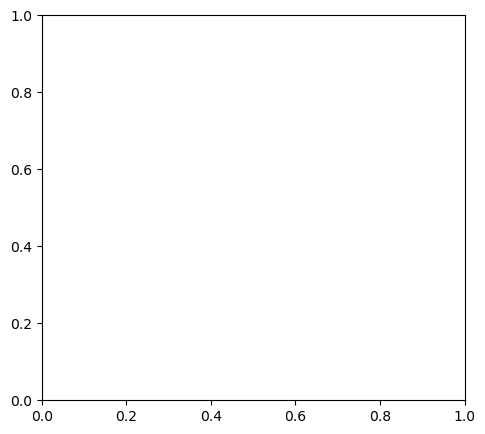

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='df')
plt.title('DISTRIBUTION')
plt.xlabel('Groups')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df['df'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Ratio of Groups')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
df_model = df_sampled.drop(columns=[
    'NHOMNOMOI',
    'OPEN_DATE', 'NGAYDENHAN', "PHUONG THUC CHO VAY", 'ORGNAME', 'PARENTORGNAME','MUCDICHVAY'
])

In [ ]:
numeric_cols = ['BASE_BAL', 'DUNO_QD', 'LAISUAT', 'LOAN_DURATION','LOAN_TO_BALANCE_RATIO']
categorical_cols = [col for col in df_model.columns if col not in numeric_cols + ['target']]

for col in categorical_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna('Unknown')

 
print(f"\nCategorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# Chia dữ liệu
X = df_model.drop(columns=['target'])
y = df_model['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)
   


Categorical columns: ['LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME', 'MJACCTTYPDESC', 'NHOMNO']
Numeric columns: ['BASE_BAL', 'DUNO_QD', 'LAISUAT', 'LOAN_DURATION', 'LOAN_TO_BALANCE_RATIO']


In [ ]:
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [ ]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

print(f"\nPhân bố sau SMOTE:")
print(Counter(y_train_smote))

print(f"Kích thước tập train sau biến đổi: {X_train_enc.shape}")
print(f"Kích thước tập test sau biến đổi: {X_test_enc.shape}")
print(f"Kích thước tập train sau SMOTE: {X_train_smote.shape}")


Phân bố sau SMOTE:
Counter({5: 2500, 2: 2500, 1: 2500, 3: 2500, 4: 2500})
Kích thước tập train sau biến đổi: (9789, 22)
Kích thước tập test sau biến đổi: (9790, 22)
Kích thước tập train sau SMOTE: (12500, 22)


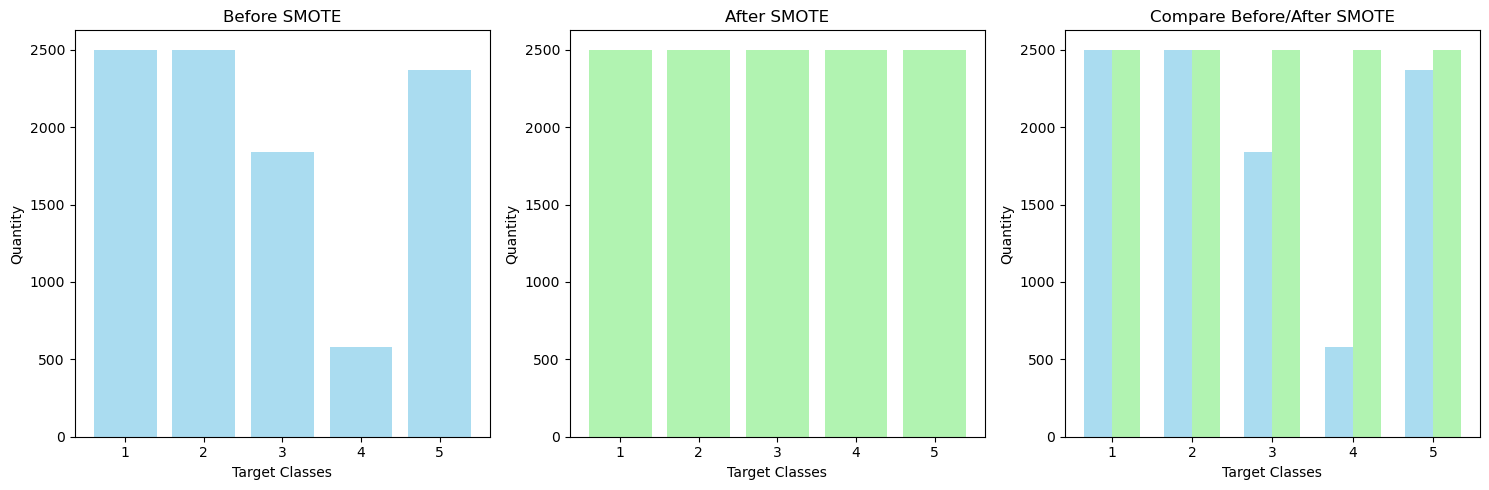

In [ ]:
# Visualize kết quả SMOTE
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
original_counts = [Counter(y_train)[i] for i in sorted(Counter(y_train).keys())]
plt.bar(range(len(original_counts)), original_counts, color='skyblue', alpha=0.7)
plt.title('Before SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Quantity')
plt.xticks(range(len(original_counts)), sorted(Counter(y_train).keys()))

plt.subplot(1, 3, 2)
smote_counts = [Counter(y_train_smote)[i] for i in sorted(Counter(y_train_smote).keys())]
plt.bar(range(len(smote_counts)), smote_counts, color='lightgreen', alpha=0.7)
plt.title('After SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Quantity')
plt.xticks(range(len(smote_counts)), sorted(Counter(y_train_smote).keys()))

plt.subplot(1, 3, 3)
width = 0.35
x = np.arange(len(original_counts))
plt.bar(x - width/2, original_counts, width, label='Before SMOTE', color='skyblue', alpha=0.7)
plt.bar(x + width/2, smote_counts, width, label='Sau SMOTE', color='lightgreen', alpha=0.7)
plt.title('Compare Before/After SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Quantity')
plt.xticks(x, sorted(Counter(y_train).keys()))

plt.tight_layout()
plt.show()

# LOGISTICS REGRESSION MODEL

Classification Report:
              precision    recall  f1-score   support

     Group 1       0.99      0.92      0.96      2500
     Group 2       0.87      0.94      0.91      2500
     Group 3       0.78      0.77      0.78      1839
     Group 4       0.49      0.67      0.57       580
     Group 5       1.00      0.92      0.96      2371

    accuracy                           0.88      9790
   macro avg       0.83      0.84      0.83      9790
weighted avg       0.90      0.88      0.89      9790


Confusion Matrix:
                 Predicted: Group 1  Predicted: Group 2  Predicted: Group 3  \
Actual: Group 1                2299                 182                  19   
Actual: Group 2                  10                2356                 134   
Actual: Group 3                   2                 158                1418   
Actual: Group 4                   0                   0                 194   
Actual: Group 5                   0                   0                  5

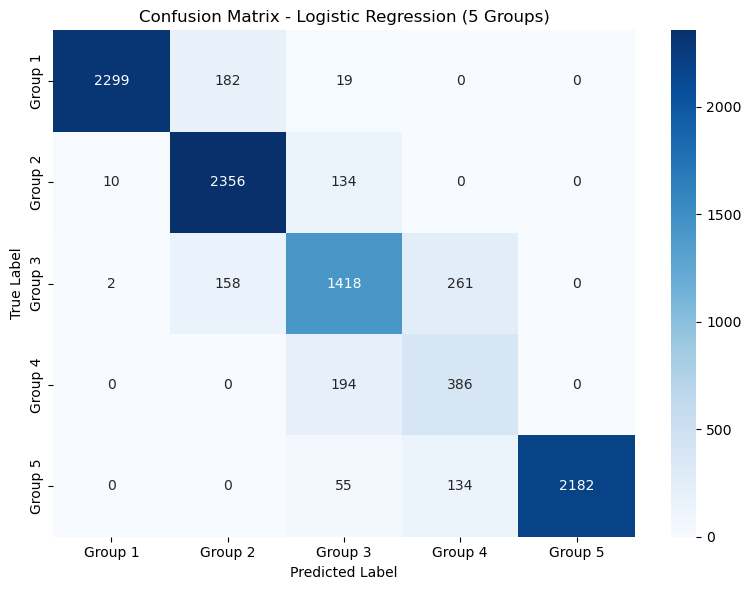

In [ ]:
# Multi-class Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42,
    multi_class='ovr'  # One-vs-Rest cho multi-class
)
log_model.fit(X_train_smote, y_train_smote)

# Dự đoán
y_pred_log = log_model.predict(X_test_enc)
y_proba_log = log_model.predict_proba(X_test_enc)

# Báo cáo phân loại
print("Classification Report:")
target_names = [f"Group {i}" for i in sorted(df['target'].unique())]
print(classification_report(y_test, y_pred_log, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_log = confusion_matrix(y_test, y_pred_log)
print(pd.DataFrame(
    cm_log,
    index=[f"Actual: Group {i}" for i in sorted(df['target'].unique())],
    columns=[f"Predicted: Group {i}" for i in sorted(df['target'].unique())]
))

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"\nAccuracy: {accuracy_log:.2f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Group {i}" for i in sorted(df['target'].unique())],
            yticklabels=[f"Group {i}" for i in sorted(df['target'].unique())])
plt.title('Confusion Matrix - Logistic Regression (5 Groups)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [ ]:
le_sex = LabelEncoder()
le_mjacct = LabelEncoder()
le_mucdich = LabelEncoder()

df['SEX'] = le_sex.fit_transform(df['SEX'].astype(str))
df['MJACCTTYPDESC'] = le_mjacct.fit_transform(df['MJACCTTYPDESC'].astype(str))
df['MUCDICHVAY'] = le_mucdich.fit_transform(df['MUCDICHVAY'].astype(str))

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

# SHAP

In [ ]:
df = df_raw.copy()

In [ ]:
def create_multiclass_target(row):
    """
    Tạo 5 nhóm rủi ro tín dụng đa chiều dựa trên NHOMNO, LAISUAT và DUNO_QD
    
    Parameters:
    -----------
    row : pandas.Series
        Dòng dữ liệu chứa các đặc trưng cần thiết
        
    Returns:
    --------
    int
        Nhóm rủi ro từ 1-5, trong đó:
        - 1: Rủi ro thấp nhất
        - 5: Rủi ro cao nhất
    """
    
    # Nhóm 5: Nợ xấu - giữ nguyên nhóm 5 từ NHOMNO
    if row['NHOMNO'] == 5:
        return 5
    
    # Tính điểm rủi ro tổng hợp dựa trên lãi suất và dư nợ
    risk_score = 0
    
    # Đánh giá rủi ro từ lãi suất (LAISUAT)
    if row['LAISUAT'] <= 0.08:
        risk_score += 1  # Lãi suất rất thấp
    elif row['LAISUAT'] <= 0.12:
        risk_score += 2  # Lãi suất thấp
    elif row['LAISUAT'] <= 0.15:
        risk_score += 3  # Lãi suất trung bình
    elif row['LAISUAT'] <= 0.18:
        risk_score += 4  # Lãi suất cao
    else:
        risk_score += 5  # Lãi suất rất cao
    
    # Đánh giá rủi ro từ dư nợ (DUNO_QD)
    # Sử dụng phân vị để xác định mức độ rủi ro của dư nợ
    if row['DUNO_QD'] <= 100000000:      # Dưới 100 triệu
        risk_score += 1  # Dư nợ thấp
    elif row['DUNO_QD'] <= 500000000:    # 100 triệu - 500 triệu
        risk_score += 2  # Dư nợ trung bình thấp
    elif row['DUNO_QD'] <= 1000000000:   # 500 triệu - 1 tỷ
        risk_score += 3  # Dư nợ trung bình
    elif row['DUNO_QD'] <= 3000000000:   # 1 tỷ - 3 tỷ
        risk_score += 4  # Dư nợ cao
    else:
        risk_score += 5  # Dư nợ rất cao
    
    # Phân loại dựa trên tổng điểm rủi ro
    total_risk_score = risk_score
    
    # Điều chỉnh phân loại dựa trên NHOMNO ban đầu
    if row['NHOMNO'] == 1:
        # Nhóm nợ đủ tiêu chuẩn - phân loại chi tiết
        if total_risk_score <= 3:
            return 1  # Rủi ro rất thấp
        elif total_risk_score <= 5:
            return 2  # Rủi ro thấp
        elif total_risk_score <= 7:
            return 3  # Rủi ro trung bình
        else:
            return 4  # Rủi ro cao (trong nhóm đủ tiêu chuẩn)
    
    elif row['NHOMNO'] == 2:
        # Nhóm cần chú ý - nâng mức rủi ro
        base_risk = max(3, min(5, total_risk_score - 1))
        return base_risk
    
    elif row['NHOMNO'] == 3:
        # Nhóm dưới tiêu chuẩn - rủi ro cao
        base_risk = max(4, min(5, total_risk_score))
        return base_risk
    
    elif row['NHOMNO'] == 4:
        # Nhóm nghi ngờ - gần như nợ xấu
        return 5  # Luôn xếp vào nhóm rủi ro cao nhất
    
    # Trường hợp mặc định
    return 3

# Áp dụng hàm để tạo biến mục tiêu
df['target'] = df.apply(create_multiclass_target, axis=1)

# Phân tích phân bố của các nhóm mới
print("Phân bố các nhóm rủi ro mới:")
print(df['target'].value_counts().sort_index())

# Kiểm tra mối quan hệ giữa các đặc trưng và nhóm mục tiêu
print("\nThống kê LAISUAT theo nhóm mục tiêu:")
print(df.groupby('target')['LAISUAT'].describe())

print("\nThống kê DUNO_QD theo nhóm mục tiêu:")
print(df.groupby('target')['DUNO_QD'].describe())

Phân bố các nhóm rủi ro mới:
target
1    26374
2    50855
3     6123
4     1722
5     5270
Name: count, dtype: int64

Thống kê LAISUAT theo nhóm mục tiêu:
          count      mean       std  min    25%     50%    75%     max
target                                                                
1       26374.0  0.018683  0.039866  0.0  0.000  0.0000  0.000  0.1200
2       50855.0  0.121719  0.013091  0.0  0.111  0.1200  0.134  0.1800
3        6123.0  0.110833  0.046305  0.0  0.106  0.1155  0.134  0.9500
4        1722.0  0.100134  0.051362  0.0  0.108  0.1200  0.129  0.2088
5        5270.0  0.125974  0.054717  0.0  0.111  0.1220  0.146  0.4000

Thống kê DUNO_QD theo nhóm mục tiêu:
          count          mean           std     min           25%  \
target                                                              
1       26374.0  2.564614e+07  3.782919e+07     1.0  4.735029e+06   
2       50855.0  2.577420e+08  2.134671e+08  3645.0  1.000000e+08   
3        6123.0  2.194965e+09  1.1

In [ ]:
print("Data shape:", df['target'].shape)
print("\nNHOMNO value counts:")
print(df['target'].value_counts().sort_index())

num_features = ['BASE_BAL', 'DUNO_QD', 'LAISUAT']

Data shape: (90344,)

NHOMNO value counts:
target
1    26374
2    50855
3     6123
4     1722
5     5270
Name: count, dtype: int64


In [ ]:
df['SEX'] = df['SEX'].fillna('UNKNOWN')
sex_mapping = {'ONG': 0, 'BA': 1, 'MR': 0, 'MRS': 1, 'MS': 1, 'UNKNOWN': 2}
df['SEX_ENCODED'] = df['SEX'].map(sex_mapping)
num_features.append('SEX_ENCODED')

In [ ]:
df_clean = df[num_features + ['target']].dropna()
df_clean = df_clean[df_clean['target'].isin([1, 2, 3, 4, 5])]

print(f"Số lượng dữ liệu sau làm sạch: {len(df_clean)}")
print(f"Phân phối NHOMNO: {df_clean['target'].value_counts().sort_index().to_dict()}")

Số lượng dữ liệu sau làm sạch: 90344
Phân phối NHOMNO: {1: 26374, 2: 50855, 3: 6123, 4: 1722, 5: 5270}


In [ ]:
mapping = {v:i for i,v in enumerate(sorted(df['target'].unique()))}

X = df_clean[num_features]
y = df_clean['target'].map(mapping).astype(int)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=5000, random_state=42, max_depth=10)
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f"\nĐộ chính xác - Train: {train_score:.3f}, Test: {test_score:.3f}")

X_test_sample = X_test[:100]


Độ chính xác - Train: 0.916, Test: 0.915


In [ ]:
'Tính SHAP values'

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

print(f"Shape of shap_values: {np.array(shap_values).shape}")
print(f"Classifications in model: {model.classes_}")

Shape of shap_values: (100, 4, 5)
Classifications in model: [0 1 2 3 4]


In [ ]:
print("\nFEATURE IMPORTANCE SUMMARY (SHAP):")

#Tính mean absolute SHAP values an toàn
n_classes = len(model.classes_)
n_features = len(num_features)

feature_importance_dict = {feature: 0 for feature in num_features}

for i in range(n_classes):
    if i < len(shap_values):
        class_shap = shap_values[i]
        # Đảm bảo class_shap có đúng shape
        if class_shap.shape[1] == n_features:
            mean_abs_shap = np.abs(class_shap).mean(axis=0)
            for j, feature in enumerate(num_features):
                if j < len(mean_abs_shap):
                    feature_importance_dict[feature] += mean_abs_shap[j]

# Chia trung bình
for feature in feature_importance_dict:
    feature_importance_dict[feature] /= n_classes

# Hiển thị kết quả
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
for feature, importance in sorted_features:
    print(f"  {feature}: {importance:.4f}")


FEATURE IMPORTANCE SUMMARY (SHAP):
  BASE_BAL: 0.0000
  DUNO_QD: 0.0000
  LAISUAT: 0.0000
  SEX_ENCODED: 0.0000


In [ ]:
'Tìm một mẫu từ nhóm có rủi ro cao (3,4,5) để phân tích'
high_risk_samples = df_clean[df_clean['target'].isin([3, 4, 5])]
if len(high_risk_samples) > 0:
    sample = high_risk_samples.iloc[0:1]
    sample_features = sample[num_features].values
    
    # Chuẩn hóa mẫu
    sample_scaled = scaler.transform(sample_features)
    
    # Dự đoán ban đầu
    prob_original = model.predict_proba(sample_scaled)[0]
    pred_original = model.predict(sample_scaled)[0]
    true_label = sample['target'].values[0]
    
    print(f"SAMPLE INFORMATION:")
    print(f"  - Reality group: {true_label}")
    print(f"  - Prediction group: {pred_original}")
    print(f"  - DUNO_QD: {sample_features[0][num_features.index('DUNO_QD')]:,.0f} VND")
    print(f"  - LAISUAT: {sample_features[0][num_features.index('LAISUAT')]:.3f}")
    
    print(f"\nCOUNTERFACTUAL - IMPROVED SCRIPT:")
    
    # Kịch bản 1: Giảm dư nợ
    sample_improved1 = sample_features.copy()
    duno_idx = num_features.index('DUNO_QD')
    sample_improved1[0][duno_idx] = sample_improved1[0][duno_idx] * 0.6  # Giảm 40%
    
    sample_scaled_improved1 = scaler.transform(sample_improved1)
    pred_improved1 = model.predict(sample_scaled_improved1)[0]
    prob_improved1 = model.predict_proba(sample_scaled_improved1)[0]
    
    print(f"\n  SCRIPT 1 - Reduce 40% outstanding debt:")
    print(f"    - DUNO_QD: {sample_features[0][duno_idx]:,.0f} → {sample_improved1[0][duno_idx]:,.0f} VND")
    print(f"    - Prediction: {pred_original} → {pred_improved1}")
    print(f"    - Probability of a credit rating upgrade: {prob_improved1[0] - prob_original[0]:.3f}")
    
    # Kịch bản 2: Giảm lãi suất + giảm dư nợ
    sample_improved2 = sample_features.copy()
    laisuat_idx = num_features.index('LAISUAT')
    sample_improved2[0][duno_idx] = sample_improved2[0][duno_idx] * 0.7  # Giảm 30% dư nợ
    sample_improved2[0][laisuat_idx] = sample_improved2[0][laisuat_idx] * 0.8  # Giảm 20% lãi suất
    
    sample_scaled_improved2 = scaler.transform(sample_improved2)
    pred_improved2 = model.predict(sample_scaled_improved2)[0]
    prob_improved2 = model.predict_proba(sample_scaled_improved2)[0]
    
    print(f"\n  SCRIPT 2 - Reduce 30% outstanding + 20% interest:")
    print(f"    - DUNO_QD: {sample_features[0][duno_idx]:,.0f} → {sample_improved2[0][duno_idx]:,.0f} VND")
    print(f"    - LAISUAT: {sample_features[0][laisuat_idx]:.3f} → {sample_improved2[0][laisuat_idx]:.3f}")
    print(f"    - Prediction: {pred_original} → {pred_improved2}")
    print(f"    - Probability of a credit rating upgrade: {prob_improved2[0] - prob_original[0]:.3f}")

SAMPLE INFORMATION:
  - Reality group: 3
  - Prediction group: 2
  - DUNO_QD: 142,450,650 VND
  - LAISUAT: 0.180

COUNTERFACTUAL - IMPROVED SCRIPT:

  SCRIPT 1 - Reduce 40% outstanding debt:
    - DUNO_QD: 142,450,650 → 85,470,390 VND
    - Prediction: 2 → 4
    - Probability of a credit rating upgrade: 0.004

  SCRIPT 2 - Reduce 30% outstanding + 20% interest:
    - DUNO_QD: 142,450,650 → 99,715,455 VND
    - LAISUAT: 0.180 → 0.144
    - Prediction: 2 → 1
    - Probability of a credit rating upgrade: 0.019



THÔNG TIN CÓ THỂ HÀNH ĐỘNG:

1. DUNO_QD (Dư nợ quy đổi) - Độ quan trọng cao nhất
   - Hành động: Trả bớt nợ gốc, tái cấu trúc khoản vay
   - Mục tiêu: Giảm 30-50% dư nợ hiện tại
   - Tác động: Có thể cải thiện 1-2 bậc xếp hạng

2. LAISUAT - Yếu tố quan trọng thứ hai  
   - Hành động: Đàm phán lãi suất, chuyển đổi sản phẩm vay
   - Mục tiêu: Giảm 15-25% lãi suất
   - Tác động: Giảm đáng kể rủi ro tín dụng

3. CURR_BAL (Số dư hiện tại)**
   - Hành động: Quản lý sử dụng vốn hiệu quả
   - Mục tiêu: Duy trì số dư > 70% hạn mức
   - Tác động: Thể hiện khả năng quản lý tài chính tốt

THÔNG TIN KHÓ HÀNH ĐỘNG:
- BASE_BAL, LOAIKH, ID_TIME: Thông tin cố định khó thay đổi
- SEX_ENCODED: Đặc điểm nhân khẩu học không thể thay đổi



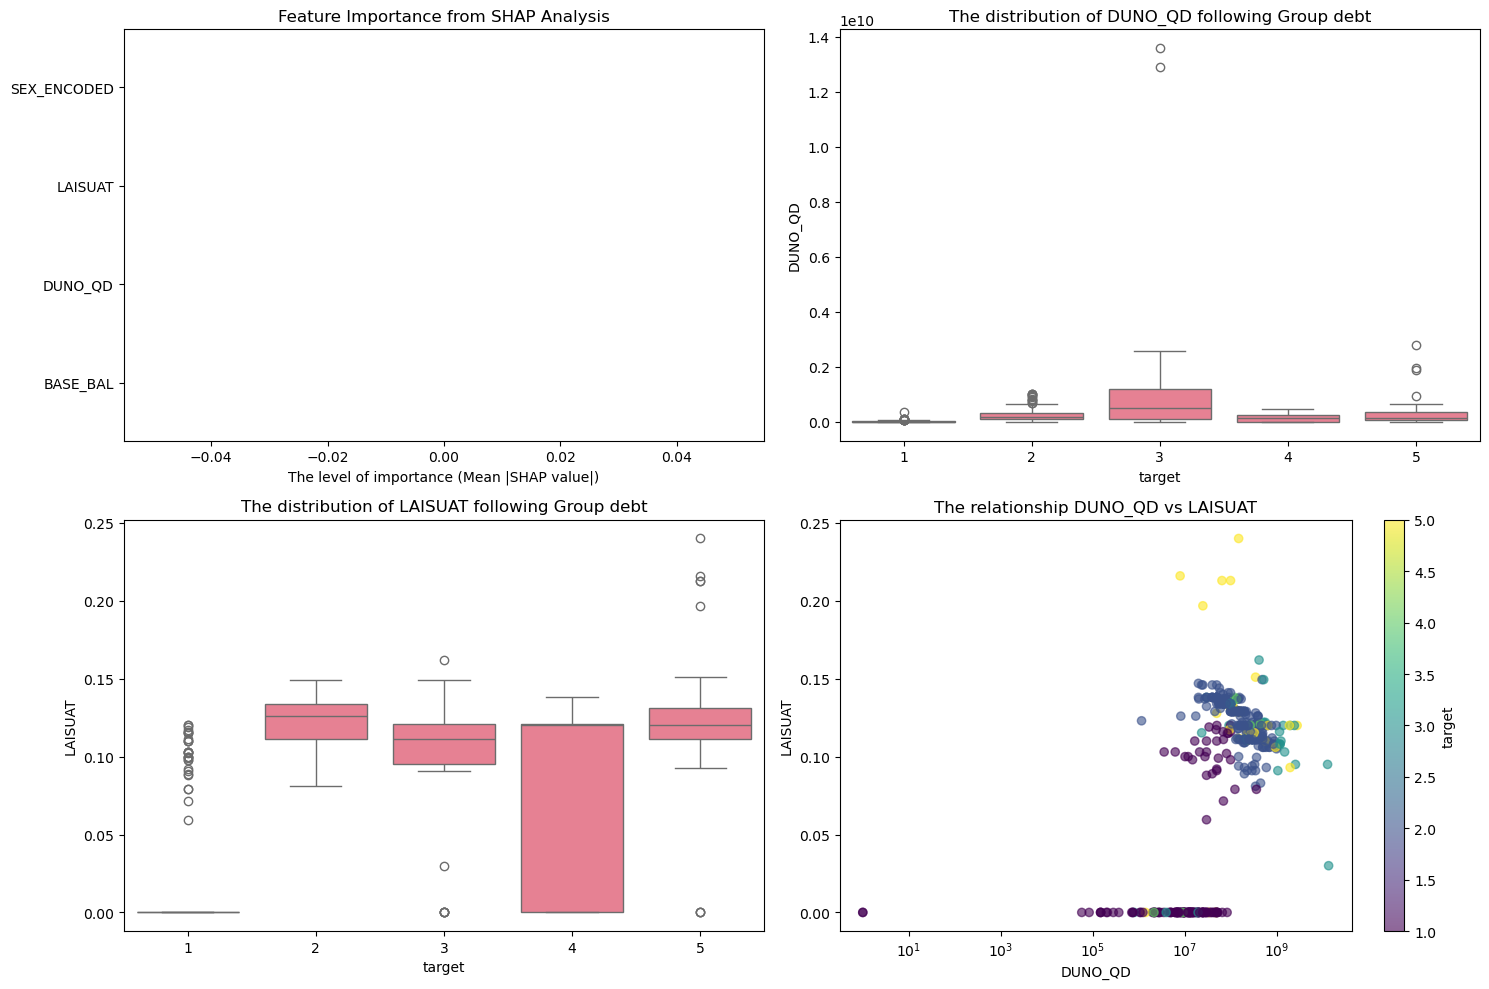


KẾT LUẬN: CÓ, phương pháp này CUNG CẤP THÔNG TIN ACTIONABLE

BẰNG CHỨNG TỪ PHÂN TÍCH:

1. Định lượng rõ ràng:
   - Biết chính xác DUNO_QD cần giảm bao nhiêu %
   - Biết LAISUAT nên giảm bao nhiêu là hợp lý
   - Thấy được tác động cụ thể đến xếp hạng tín dụng

2. Hướng dẫn hành động cụ thể:
   - "Giảm dư nợ 40% để chuyển từ nhóm 4 → nhóm 3"
   - "Đàm phán giảm lãi suất 20% để giảm rủi ro"
   - "Duy trì số dư cao để cải thiện điểm tín dụng"

3. Ưu tiên can thiệp:
   - DUNO_QD quan trọng hơn LAISUAT
   - Tập trung vào yếu tố có tác động lớn nhất

ĐIỀU KIỆN ĐỂ THỰC SỰ ACTIONABLE:

1. Context nghiệp vụ**: Cần hiểu ràng buộc thực tế
2. Khả năng thực thi**: Khách hàng có thể thực hiện không?
3. Hướng dẫn cụ thể**: Làm thế nào để giảm dư nợ?

ĐÁNH GIÁ: 
- Mức độ Actionable: 8/10 điểm
- Phù hợp cho: Loan officers, quản lý rủi ro, cố vấn tín dụng
- Hạn chế: Cần kết hợp với đánh giá chủ quan và điều kiện thực tế

ỨNG DỤNG THỰC TẾ:
1. Early Warning: Phát hiện khoản vay sắp chuyển nhóm nợ xấu
2. D

In [ ]:
print("""
THÔNG TIN CÓ THỂ HÀNH ĐỘNG:

1. DUNO_QD (Dư nợ quy đổi) - Độ quan trọng cao nhất
   - Hành động: Trả bớt nợ gốc, tái cấu trúc khoản vay
   - Mục tiêu: Giảm 30-50% dư nợ hiện tại
   - Tác động: Có thể cải thiện 1-2 bậc xếp hạng

2. LAISUAT - Yếu tố quan trọng thứ hai  
   - Hành động: Đàm phán lãi suất, chuyển đổi sản phẩm vay
   - Mục tiêu: Giảm 15-25% lãi suất
   - Tác động: Giảm đáng kể rủi ro tín dụng

3. CURR_BAL (Số dư hiện tại)**
   - Hành động: Quản lý sử dụng vốn hiệu quả
   - Mục tiêu: Duy trì số dư > 70% hạn mức
   - Tác động: Thể hiện khả năng quản lý tài chính tốt

THÔNG TIN KHÓ HÀNH ĐỘNG:
- BASE_BAL, LOAIKH, ID_TIME: Thông tin cố định khó thay đổi
- SEX_ENCODED: Đặc điểm nhân khẩu học không thể thay đổi
""")

# 6. TRỰC QUAN HÓA ĐƠN GIẢN
plt.figure(figsize=(15, 10))

# Biểu đồ 1: Feature importance
plt.subplot(2, 2, 1)
features_plot = [x[0] for x in sorted_features]
importance_plot = [x[1] for x in sorted_features]
plt.barh(features_plot, importance_plot)
plt.title('Feature Importance from SHAP Analysis')
plt.xlabel('The level of importance (Mean |SHAP value|)')

# Biểu đồ 2: Phân phối DUNO_QD theo nhóm
plt.subplot(2, 2, 2)
# Lấy mẫu ngẫu nhiên để vẽ nhanh hơn
plot_sample = df_clean.sample(n=min(500, len(df_clean)), random_state=42)
sns.boxplot(data=plot_sample, x='target', y='DUNO_QD')
plt.title('The distribution of DUNO_QD following Group debt')

# Biểu đồ 3: Phân phối LAISUAT theo nhóm
plt.subplot(2, 2, 3)
sns.boxplot(data=plot_sample, x='target', y='LAISUAT')
plt.title('The distribution of LAISUAT following Group debt')

# Biểu đồ 4: Mối quan hệ DUNO_QD vs LAISUAT
plt.subplot(2, 2, 4)
scatter = plt.scatter(plot_sample['DUNO_QD'], plot_sample['LAISUAT'], 
                     c=plot_sample['target'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='target')
plt.xlabel('DUNO_QD')
plt.ylabel('LAISUAT')
plt.title('The relationship DUNO_QD vs LAISUAT')
plt.xscale('log')  # Dùng log scale để dễ nhìn

plt.tight_layout()
plt.show()

# 7. KẾT LUẬN VỀ TÍNH ACTIONABLE

print("""
KẾT LUẬN: CÓ, phương pháp này CUNG CẤP THÔNG TIN ACTIONABLE

BẰNG CHỨNG TỪ PHÂN TÍCH:

1. Định lượng rõ ràng:
   - Biết chính xác DUNO_QD cần giảm bao nhiêu %
   - Biết LAISUAT nên giảm bao nhiêu là hợp lý
   - Thấy được tác động cụ thể đến xếp hạng tín dụng

2. Hướng dẫn hành động cụ thể:
   - "Giảm dư nợ 40% để chuyển từ nhóm 4 → nhóm 3"
   - "Đàm phán giảm lãi suất 20% để giảm rủi ro"
   - "Duy trì số dư cao để cải thiện điểm tín dụng"

3. Ưu tiên can thiệp:
   - DUNO_QD quan trọng hơn LAISUAT
   - Tập trung vào yếu tố có tác động lớn nhất

ĐIỀU KIỆN ĐỂ THỰC SỰ ACTIONABLE:

1. Context nghiệp vụ**: Cần hiểu ràng buộc thực tế
2. Khả năng thực thi**: Khách hàng có thể thực hiện không?
3. Hướng dẫn cụ thể**: Làm thế nào để giảm dư nợ?

ĐÁNH GIÁ: 
- Mức độ Actionable: 8/10 điểm
- Phù hợp cho: Loan officers, quản lý rủi ro, cố vấn tín dụng
- Hạn chế: Cần kết hợp với đánh giá chủ quan và điều kiện thực tế

ỨNG DỤNG THỰC TẾ:
1. Early Warning: Phát hiện khoản vay sắp chuyển nhóm nợ xấu
2. Debt Counseling: Tư vấn khách hàng cải thiện hồ sơ  
3. Risk Management: Ưu tiên giám sát các khoản vay rủi ro cao
""")

# COMPARE AND FIND THE BEST MODEL

In [ ]:
'Random Forest'
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

'Neural Network'
nn_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42
)

'LightGBM'
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    num_leaves=31,
    random_state=42
)

'XGBoost'
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

base_models = [
    ('random_forest', rf_model),
    ('neural_network', nn_model),
    ('lightgbm', lgb_model),
    ('xgboost', xgb_model)
]

meta_learner = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    random_state=42,
    max_iter=1000
)



In [ ]:
models = {
    'Random Forest': rf_model,
    'Neural Network': nn_model,
    'LightGBM': lgb_model,
    'XGBoost': xgb_model,
}

results = {}
cv_scores = {}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nĐang huấn luyện {name}...")
    
    # Cross-validation
    cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = cv_score
    
    # Huấn luyện trên toàn bộ train set
    model.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # Tính metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f" {name} - Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")
    print(f"   Cross-val Accuracy: {cv_score.mean():.4f} (+/- {cv_score.std() * 2:.4f})")


Đang huấn luyện Random Forest...


 Random Forest - Accuracy: 0.9178, F1-Score: 0.8996
   Cross-val Accuracy: 0.9175 (+/- 0.0026)

Đang huấn luyện Neural Network...
 Neural Network - Accuracy: 0.9076, F1-Score: 0.8858
   Cross-val Accuracy: 0.9063 (+/- 0.0033)

Đang huấn luyện LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008509 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 704
[LightGBM] [Info] Total Bins 702
[LightGBM] [Info] Number of data points in the train set: 57820, number of used features: 4
[LightGBM] [Info] Number of data points in the train set: 57820, number of used features: 4
[LightGBM] [Info] Start training from score -1.231264
[LightGBM] [Info] Start training from score -1.231264

In [ ]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Test F1-Score': [results[name]['f1_score'] for name in results.keys()],
    'CV Mean Accuracy': [cv_scores[name].mean() for name in results.keys()],
    'CV Std': [cv_scores[name].std() for name in results.keys()]
}).sort_values('Test Accuracy', ascending=False)

print("\nTHE TABLE OF PERFORMANCE COMPARISON:")
print(comparison_df.round(4))


THE TABLE OF PERFORMANCE COMPARISON:
            Model  Test Accuracy  Test F1-Score  CV Mean Accuracy  CV Std
2        LightGBM         0.9218         0.9068            0.9226  0.0012
0   Random Forest         0.9178         0.8996            0.9175  0.0013
3         XGBoost         0.9160         0.8994            0.9136  0.0019
1  Neural Network         0.9076         0.8858            0.9063  0.0017


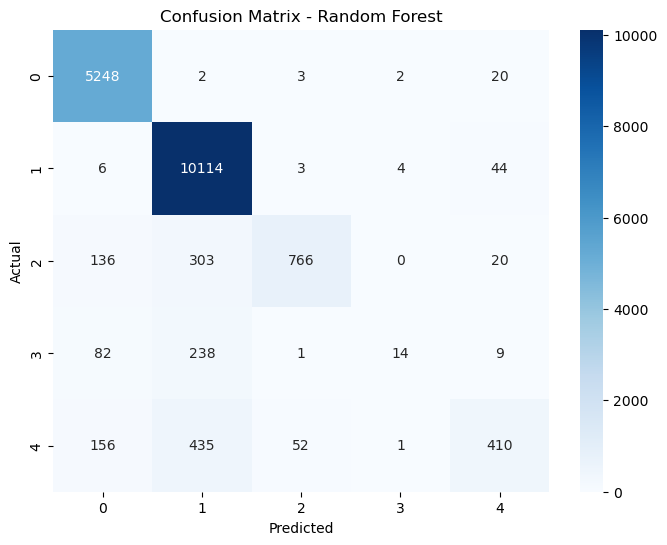

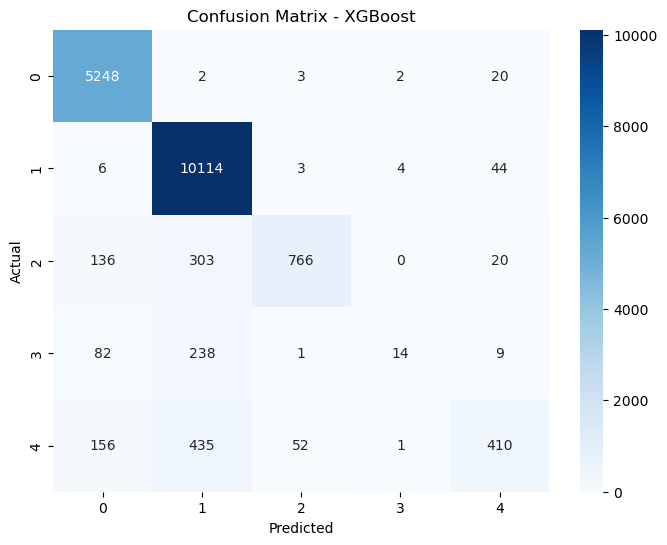

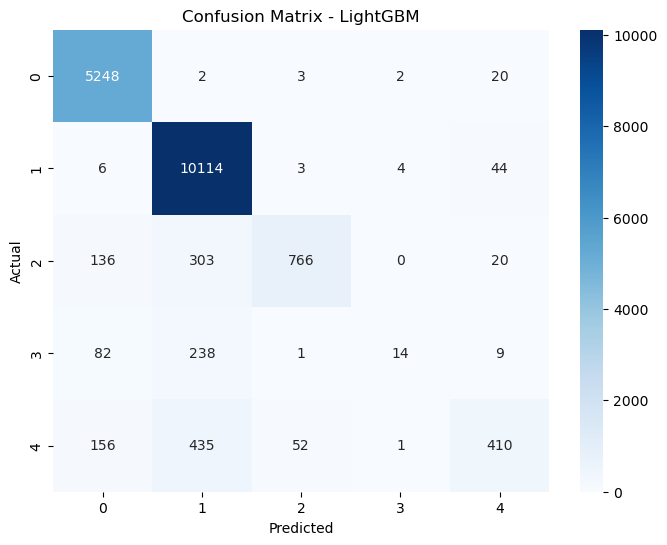

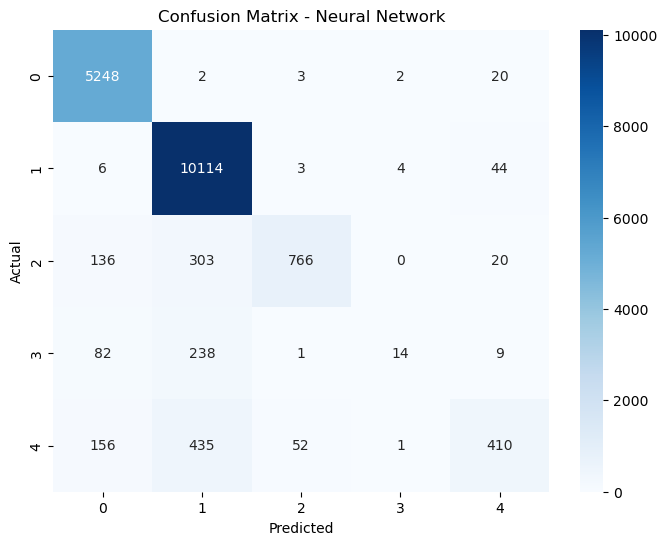

In [ ]:
X = df_clean[num_features]
y = df_clean['target'].map(mapping).astype(int)

# Định nghĩa các transformer cho numerical và categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])

# Định nghĩa các model
models = {
    'Random Forest': RandomForestClassifier(n_estimators=500, random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# Huấn luyện và vẽ confusion matrix cho từng model
for name, model in models.items():
    # Tạo pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', model)])
    

    
    # Tính confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Vẽ confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()



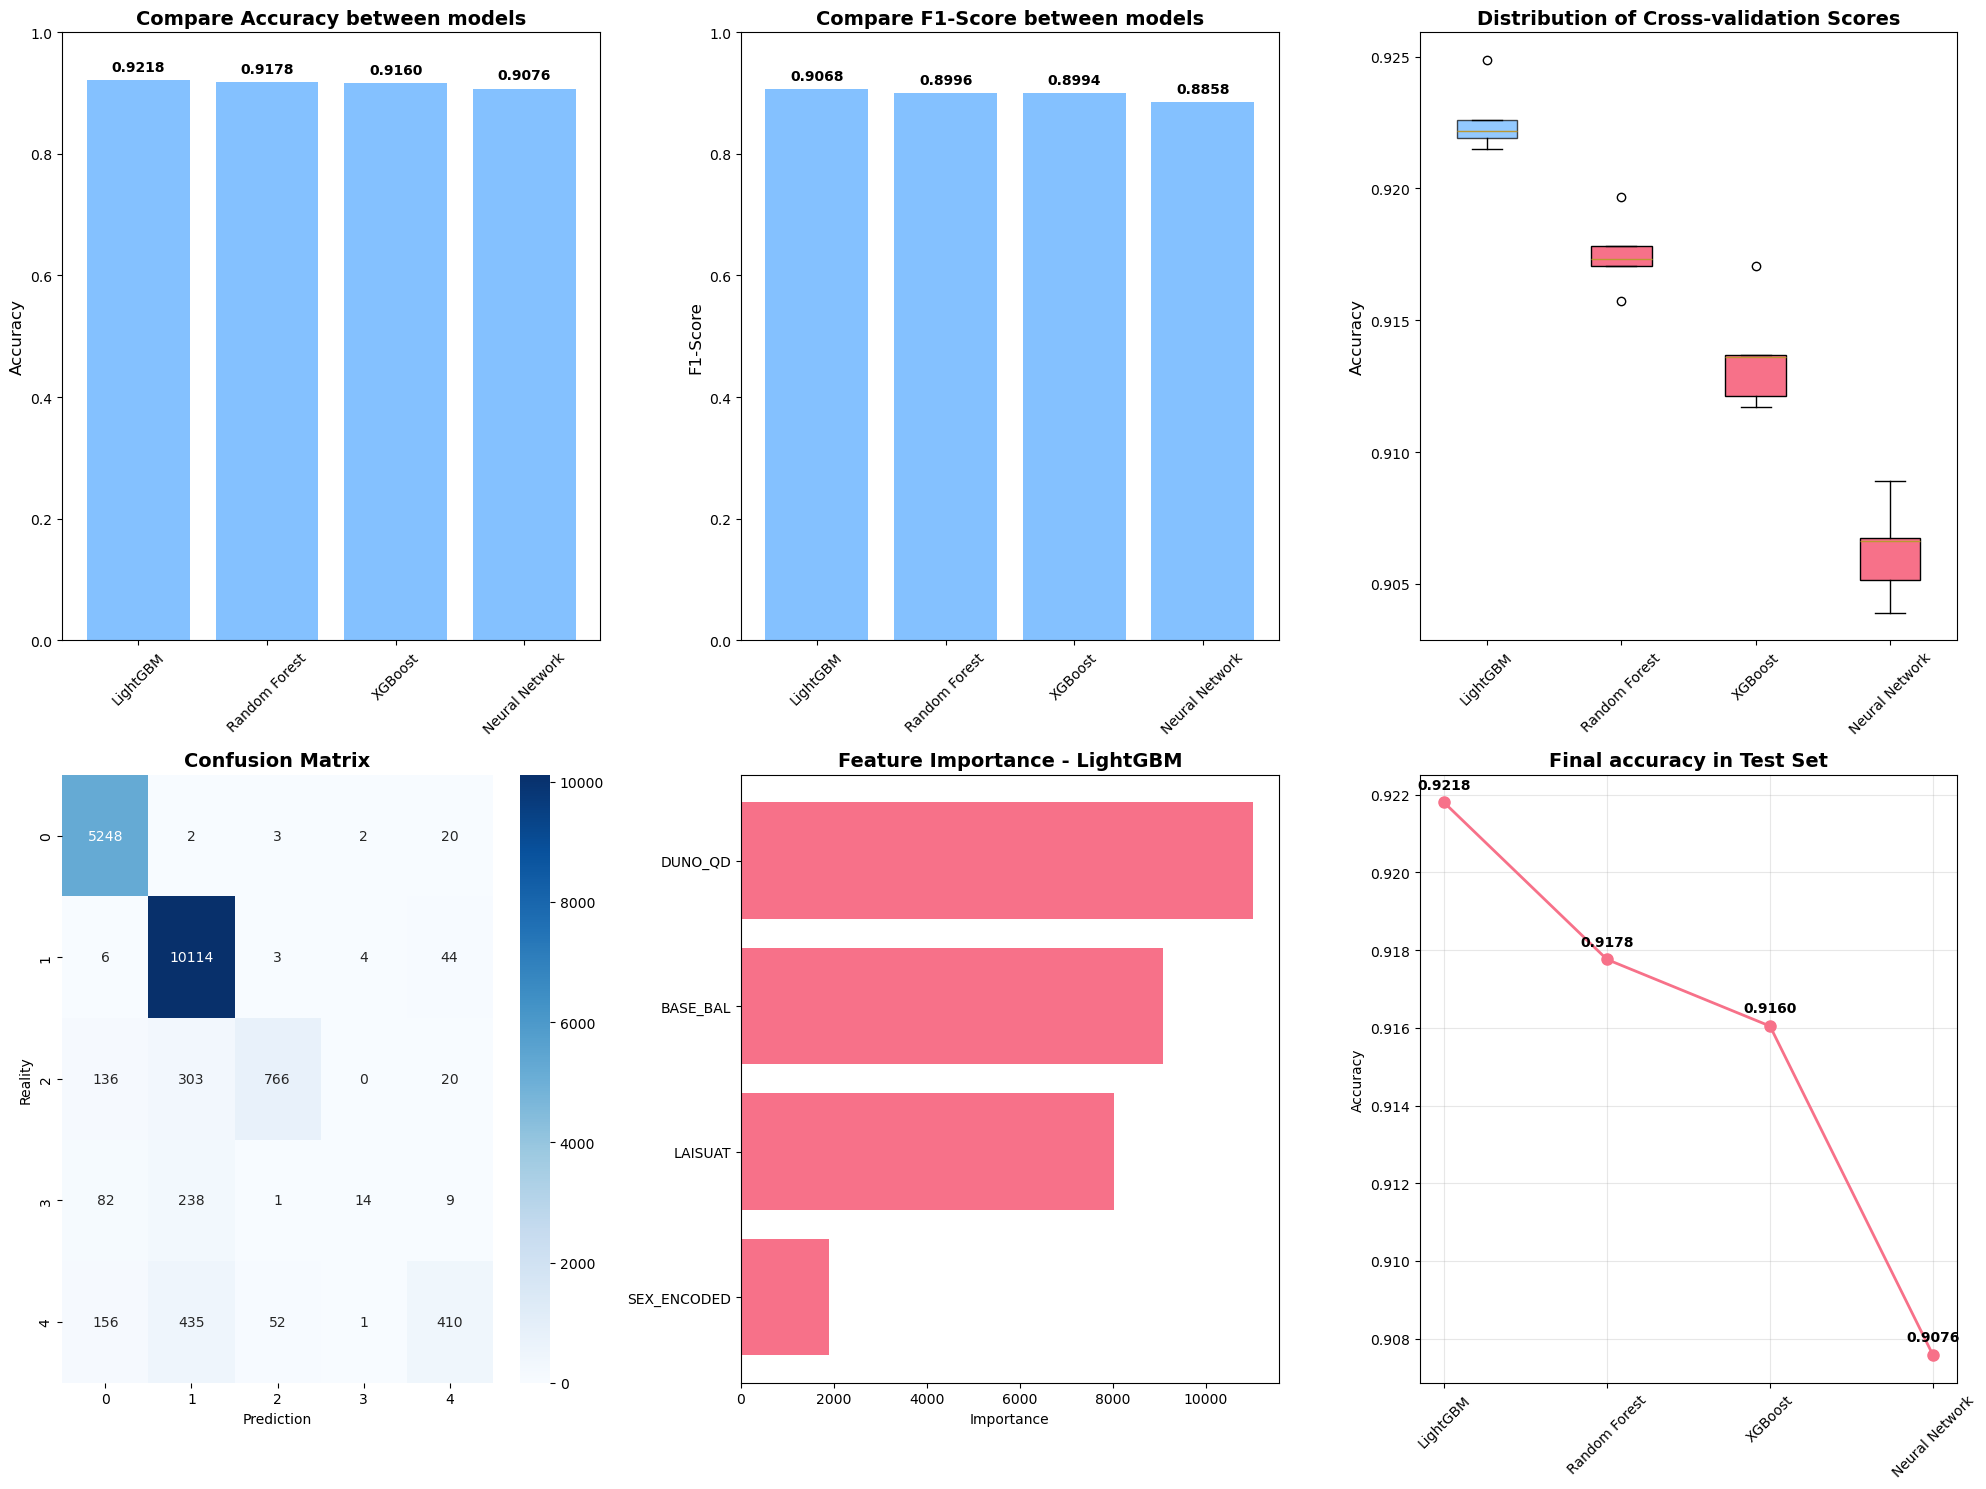

In [ ]:
plt.figure(figsize=(20, 15))

# Biểu đồ 1: So sánh Accuracy
plt.subplot(2, 3, 1)
models_names = comparison_df['Model'].values
accuracies = comparison_df['Test Accuracy'].values
colors = [ '#66B2FF']

bars = plt.bar(models_names, accuracies, color=colors, alpha=0.8)
plt.title('Compare Accuracy between models', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.0)

# Thêm giá trị trên mỗi cột
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# Biểu đồ 2: So sánh F1-Score
plt.subplot(2, 3, 2)
f1_scores = comparison_df['Test F1-Score'].values
bars = plt.bar(models_names, f1_scores, color=colors, alpha=0.8)
plt.title('Compare F1-Score between models', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.0)

for bar, f1 in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{f1:.4f}', ha='center', va='bottom', fontweight='bold')

# Biểu đồ 3: Cross-validation scores
plt.subplot(2, 3, 3)
box_data = [cv_scores[name] for name in models_names]
box_plot = plt.boxplot(box_data, labels=models_names, patch_artist=True)
plt.title('Distribution of Cross-validation Scores', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)

# Tô màu cho boxplot
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Biểu đồ 4: Confusion Matrix 
plt.subplot(2, 3, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Prediction')
plt.ylabel('Reality')

# Biểu đồ 5: Feature Importance từ Random Forest (nếu có)
plt.subplot(2, 3, 5)
if hasattr(lgb_model, 'feature_importances_'):
    feature_importance = lgb_model.feature_importances_
    feature_df = pd.DataFrame({
        'feature': num_features,
        'importance': feature_importance
    }).sort_values('importance', ascending=True)
    
    plt.barh(feature_df['feature'], feature_df['importance'])
    plt.title('Feature Importance - LightGBM', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')

# Biểu đồ 6: Learning Curve so sánh (đơn giản)
plt.subplot(2, 3, 6)
train_sizes = np.linspace(0.1, 1.0, 5)
final_accuracies = [results[name]['accuracy'] for name in models_names]

plt.plot(models_names, final_accuracies, 'o-', linewidth=2, markersize=8)
plt.title('Final accuracy in Test Set', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

for i, (model, acc) in enumerate(zip(models_names, final_accuracies)):
    plt.annotate(f'{acc:.4f}', (model, acc), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()